In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import glob
import pickle
from collections import defaultdict
from pprint import pprint

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap  # pip install umap-learn

# ActorNet concat 우선순위
ACTOR_ORDER = [
    "last_pri", "last_reset", "last_reward",
    "tree_reps_vector", "tree_reps",   # tree_reps alias 지원
    "h_vectors", "im_vectors", "real_vectors",
    "im_vp_vectors", "im_imgs",
]

action_mapping = {
    "NOOP": 0, "FIRE": 1, "RIGHT": 2, "LEFT": 3, "RIGHTFIRE": 4, "LEFTFIRE": 5
}
idx_to_action = {v: k for k, v in action_mapping.items()}


def _normalize_specs(specs):
    if specs is None:
        return []
    if isinstance(specs, str):
        return [specs]
    return list(specs)


def _order_specs_by_actor(specs):
    present = set(specs)
    ordered = [k for k in ACTOR_ORDER if k in present]
    ordered.extend([k for k in specs if k not in ordered])
    return ordered


def _flatten(arr, max_len=None):
    arr = np.asarray(arr)
    if max_len is not None:
        arr = arr[:max_len]
    if arr.ndim == 1:
        arr = arr[:, None]
    else:
        arr = arr.reshape(arr.shape[0], -1)
    return arr.astype(np.float32)


def _concat_dict_values(d):
    parts = [np.asarray(v) for v in d.values()]
    if not parts:
        raise ValueError("dict feature에 값이 없습니다.")
    common_len = min(p.shape[0] for p in parts)
    flat_parts = [_flatten(p, common_len) for p in parts]
    return np.concatenate(flat_parts, axis=1)


def _feature_from_key(data, key):
    # tree_reps / tree_reps_vector는 동일 처리
    if key in ("tree_reps_vector", "tree_reps"):
        if "tree_reps" not in data or not isinstance(data["tree_reps"], dict):
            raise KeyError("'tree_reps' dict가 data에 없습니다.")
        return _concat_dict_values(data["tree_reps"])

    if key not in data:
        raise KeyError(f"'{key}'가 data에 없습니다.")

    value = data[key]
    if isinstance(value, dict):
        return _concat_dict_values(value)

    return _flatten(value)


def vectorize_by_specs(data, specs):
    entries = []
    for key in specs:
        try:
            entries.append(_feature_from_key(data, key))
        except KeyError:
            # 없는 key는 건너뜀
            continue

    if not entries:
        raise ValueError("선택된 feature가 없습니다.")

    common_len = min(e.shape[0] for e in entries)
    entries = [e[:common_len] for e in entries]
    return np.concatenate(entries, axis=1), common_len


def pair_planning_before_real(status):
    status = np.asarray(status)
    real_idx = np.where(status == 0)[0]
    driver_idx = real_idx - 1
    mask = driver_idx >= 0
    return real_idx[mask], driver_idx[mask]


def build_driver_history_indices(status, t=0):
    """
    t=0: 현재 real step 바로 앞 driver만 사용
    t=3: [현재 real 앞 driver, 이전 1/2/3 real 앞 driver]를 함께 사용
    """
    if t < 0:
        raise ValueError("t는 0 이상의 정수여야 합니다.")

    real_idx, driver_idx = pair_planning_before_real(status)
    if len(real_idx) <= t:
        raise ValueError(
            f"유효한 real step 수({len(real_idx)})가 t({t})보다 작거나 같아서 히스토리를 만들 수 없습니다."
        )

    base = np.arange(t, len(real_idx))  # 앞쪽 t개 real은 히스토리 부족으로 제외
    real_idx_used = real_idx[base]

    # column 0 = 현재, column 1 = 이전 1-step, ...
    driver_hist = np.stack(
        [driver_idx[base - lag] for lag in range(t + 1)],
        axis=1
    )
    return real_idx_used, driver_hist


def _decode_label_array(arr):
    arr = np.asarray(arr)

    # one-hot or logits [T, A]
    if arr.ndim == 2:
        ids = np.argmax(arr, axis=1)
        return np.array([idx_to_action.get(int(i), f"A{int(i)}") for i in ids], dtype=object)

    # class id [T]
    if arr.ndim == 1 and np.issubdtype(arr.dtype, np.integer):
        return np.array([idx_to_action.get(int(i), f"A{int(i)}") for i in arr], dtype=object)

    # fallback: 문자열/기타
    return arr.astype(object)


def _extract_labels(data, label_specs, max_len, real_idx):
    label_keys = _normalize_specs(label_specs)
    if not label_keys:
        raise ValueError("label_specs를 최소 1개 지정해야 합니다. 예: 'human_action'")

    parts = []
    for key in label_keys:
        if key not in data:
            raise KeyError(f"label key '{key}'가 data에 없습니다.")
        labels_all = _decode_label_array(data[key])[:max_len]
        parts.append(labels_all[real_idx].astype(str))

    if len(parts) == 1:
        return parts[0]

    return np.array([" | ".join(x) for x in zip(*parts)], dtype=object)


def prepare_feature_matrix(data, feature_specs=None, label_specs="human_action", t=0):
    specs = _normalize_specs(feature_specs)
    specs = _order_specs_by_actor(specs)

    feature_matrix, max_len = vectorize_by_specs(data, specs)
    status = np.asarray(data["status"])[:max_len]

    real_idx, driver_hist = build_driver_history_indices(status, t=t)

    # t 히스토리 concat: [현재, -1, -2, ... -t] 순서
    feat_parts = [feature_matrix[driver_hist[:, lag]] for lag in range(driver_hist.shape[1])]
    feature_subset = np.concatenate(feat_parts, axis=1)

    labels = _extract_labels(data, label_specs, max_len, real_idx)

    # planning depth 표시(선택적)
    if "analyze_status_data" in globals():
        all_real_idx, depths, _ = analyze_status_data(status)
        depth_map = {idx: depth for idx, depth in zip(all_real_idx, depths)}
        planning_depths = np.array([depth_map.get(idx, np.nan) for idx in real_idx])
    else:
        planning_depths = np.full(real_idx.shape, np.nan)

    return feature_subset, labels, planning_depths, driver_hist, real_idx


def fit_umap(feature_matrix, n_neighbors=30, min_dist=0.1, metric="euclidean", random_state=0, pca_dim=50):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(feature_matrix)

    # optional PCA (속도/노이즈 감소용)
    reduced = scaled
    max_pca = min(scaled.shape[1], scaled.shape[0] - 1)
    if pca_dim is not None and pca_dim >= 2 and max_pca >= 2:
        pca_k = min(pca_dim, max_pca)
        reduced = PCA(n_components=pca_k, random_state=random_state).fit_transform(scaled)

    if reduced.shape[0] < 3:
        raise ValueError("UMAP 실행을 위해 최소 3개 샘플이 필요합니다.")

    nn = int(max(2, min(n_neighbors, reduced.shape[0] - 1)))

    um = umap.UMAP(
        n_components=2,
        n_neighbors=nn,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    emb = um.fit_transform(reduced)
    return np.asarray(emb)


def _load_single_npy(path):
    obj = np.load(path, allow_pickle=True)

    # np.save(dict) 케이스
    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.shape == ():
        data = obj.item()
        if isinstance(data, dict):
            return data

    # npz 케이스
    if hasattr(obj, "files"):
        return {k: obj[k] for k in obj.files}

    raise ValueError(f"{path}: dict 형태의 npy/npz를 해석할 수 없습니다.")


def _normalize_datasets(data=None, npy_files=None):
    datasets = []

    if npy_files is not None:
        files = _normalize_specs(npy_files)
        for p in files:
            datasets.append((str(p), _load_single_npy(p)))
        return datasets

    if data is None:
        raise ValueError("data 또는 npy_files 중 하나는 반드시 지정해야 합니다.")

    if isinstance(data, dict):
        return [("in_memory_0", data)]

    if isinstance(data, (list, tuple)):
        for i, d in enumerate(data):
            if not isinstance(d, dict):
                raise ValueError("data 리스트는 dict 원소들로 구성되어야 합니다.")
            datasets.append((f"in_memory_{i}", d))
        return datasets

    raise ValueError("data 형식이 올바르지 않습니다. (dict 또는 dict 리스트)")


def plot_umap(
    data=None,
    npy_files=None,
    feature_specs=None,
    label_specs="human_action",  # "human_action" 또는 ["human_action","thinker_action"]
    t=0,                         # 몇 real step 이전까지 concat할지
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=0,
    pca_dim=50,
):
    datasets = _normalize_datasets(data=data, npy_files=npy_files)

    all_feats = []
    all_labels = []
    all_depths = []
    all_driver_idx = []
    all_real_idx = []
    all_source_name = []

    for source_name, one_data in datasets:
        feats, labels, depths, driver_hist, real_idx = prepare_feature_matrix(
            one_data,
            feature_specs=feature_specs,
            label_specs=label_specs,
            t=t,
        )
        all_feats.append(feats)
        all_labels.append(labels)
        all_depths.append(depths)
        all_driver_idx.append(driver_hist)
        all_real_idx.append(real_idx)
        all_source_name.append(np.array([source_name] * feats.shape[0], dtype=object))

    feature_matrix = np.concatenate(all_feats, axis=0)
    label_values = np.concatenate(all_labels, axis=0)
    planning_depths = np.concatenate(all_depths, axis=0)
    source_names = np.concatenate(all_source_name, axis=0)
    driver_idx_local = np.concatenate(all_driver_idx, axis=0)  # shape: [N, t+1]
    action_idx_local = np.concatenate(all_real_idx, axis=0)    # shape: [N]

    emb = fit_umap(
        feature_matrix,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
        pca_dim=pca_dim,
    )

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        x=emb[:, 0],
        y=emb[:, 1],
        hue=label_values,
        palette="tab10",
        alpha=0.8,
        edgecolor="none",
    )
    plt.title(f"UMAP (actor-order concat, t={t})")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)
    plt.tight_layout()
    plt.show()

    return {
        "umap_1": emb[:, 0],
        "umap_2": emb[:, 1],
        "label": label_values,
        "planning_depth": planning_depths,
        "source_file": source_names,
        # 각 포인트별 local index
        "driver_idx_local": driver_idx_local,  # [N, t+1], col0=현재 real 앞, col1=이전 real 앞...
        "action_idx_local": action_idx_local,  # [N]
    }





/home/jmme425/miniconda3/envs/thinker/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/jmme425/miniconda3/envs/thinker/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


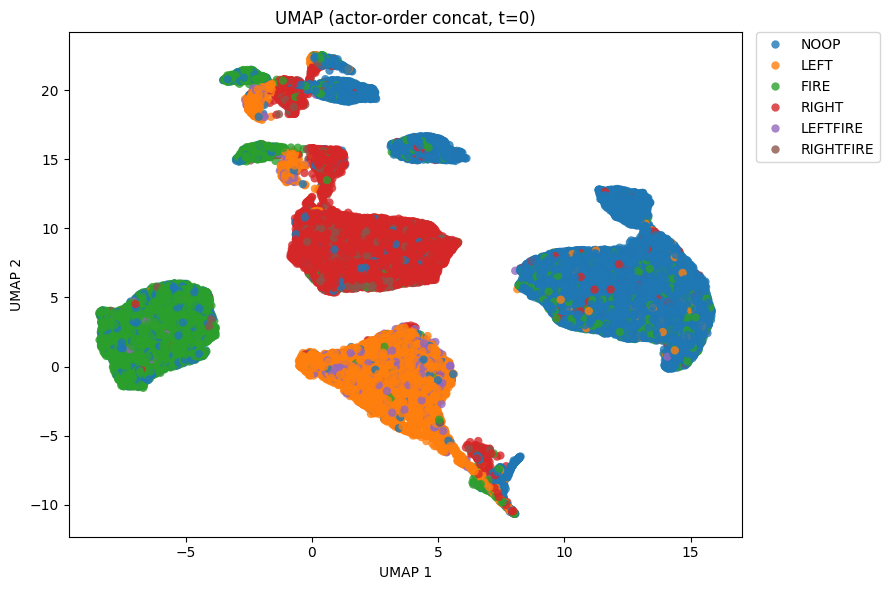

In [31]:
# 여러 npy/npz 파일을 한 번에 합쳐서 UMAP
umap_results_multi = plot_umap(
    npy_files=[
        "test/sub001/ses-04/sub001-ses04-block2-game2_000.npy",
        "test/sub001/ses-04/sub001-ses04-block2-game2_001.npy",
        "test/sub001/ses-04/sub001-ses04-block2-game2_002.npy",
        "test/sub001/ses-04/sub001-ses04-block2-game2_003.npy",
        "test/sub001/ses-04/sub001-ses04-block4-game2_000.npy",
        #"test/sub001/ses-04/sub001-ses04-block4-game2_001.npy",
        "test/sub001/ses-04/sub001-ses04-block8-game2_000.npy",
        "test/sub001/ses-04/sub001-ses04-block8-game2_001.npy",
        "test/sub001/ses-04/sub001-ses04-block8-game2_002.npy",
        "test/sub001/ses-04/sub001-ses04-block8-game2_003.npy",
        "test/sub001/ses-04/sub001-ses04-block8-game2_004.npy",
    ],
    feature_specs=["tree_reps_vector"],   # t 히스토리 적용 대상
    label_specs="human_action",
    t=0,                           # 현재 + 이전 3 real-step의 driver feature concat
    n_neighbors=25,
    min_dist=0.25,
    metric="euclidean",
    random_state=0,
    pca_dim=25,
)

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, OPTICS, KMeans
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, silhouette_score
)

def cluster_and_visualize_umap_space(
    umap_results,
    method="optics",          # "optics" | "dbscan" | "kmeans" | "hdbscan"
    scale_for_cluster=True,
    eps=0.28,                 # DBSCAN용
    min_samples=25,           # DBSCAN/OPTICS/HDBSCAN용
    min_cluster_size=25,      # OPTICS/HDBSCAN용
    xi=0.05,                  # OPTICS용
    n_clusters=6,             # KMeans용
    random_state=0,
    point_size=16,
    alpha=0.85,
):
    # 1) UMAP 2D 좌표와 액션 라벨 준비
    X = np.column_stack([umap_results["umap_1"], umap_results["umap_2"]]).astype(np.float32)
    y_action = np.asarray(umap_results["label"]).astype(str)

    Xc = StandardScaler().fit_transform(X) if scale_for_cluster else X

    # 2) 클러스터링
    if method == "dbscan":
        model = DBSCAN(eps=eps, min_samples=min_samples)
        cluster = model.fit_predict(Xc)

    elif method == "optics":
        model = OPTICS(
            min_samples=min_samples,
            min_cluster_size=min_cluster_size,
            xi=xi,
            cluster_method="xi"
        )
        cluster = model.fit_predict(Xc)

    elif method == "kmeans":
        model = KMeans(n_clusters=n_clusters, n_init=20, random_state=random_state)
        cluster = model.fit_predict(Xc)

    elif method == "hdbscan":
        try:
            import hdbscan
        except Exception as e:
            raise ImportError("hdbscan이 필요합니다. `pip install hdbscan` 후 다시 실행하세요.") from e
        model = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        cluster = model.fit_predict(Xc)

    else:
        raise ValueError("method는 'optics', 'dbscan', 'kmeans', 'hdbscan' 중 하나여야 합니다.")

    cluster = np.asarray(cluster)

    # 3) 결과 테이블
    df = pd.DataFrame({
        "umap_1": X[:, 0],
        "umap_2": X[:, 1],
        "action": y_action,
        "cluster": cluster
    })
    df["cluster_plot"] = np.where(df["cluster"] == -1, "noise", df["cluster"].astype(str))

    # 4) 시각화 (클러스터 vs 액션)
    unique_clusters = sorted([c for c in np.unique(cluster) if c != -1])
    pal = sns.color_palette("tab20", n_colors=max(len(unique_clusters), 1))
    cluster_palette = {str(cid): pal[i] for i, cid in enumerate(unique_clusters)}
    if -1 in cluster:
        cluster_palette["noise"] = (0.75, 0.75, 0.75)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.scatterplot(
        data=df, x="umap_1", y="umap_2",
        hue="cluster_plot", palette=cluster_palette,
        s=point_size, alpha=alpha, linewidth=0, ax=axes[0]
    )
    axes[0].set_title(f"Clusters on UMAP ({method})")
    axes[0].set_xlabel("UMAP 1")
    axes[0].set_ylabel("UMAP 2")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)

    sns.scatterplot(
        data=df, x="umap_1", y="umap_2",
        hue="action", palette="tab10",
        s=point_size, alpha=alpha, linewidth=0, ax=axes[1]
    )
    axes[1].set_title("Action Labels on UMAP")
    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)

    plt.tight_layout()
    plt.show()

    # 5) cluster-action 매핑표 (noise 제외)
    valid = df["cluster"] != -1
    if valid.sum() > 0:
        ct_counts = pd.crosstab(df.loc[valid, "cluster"], df.loc[valid, "action"]).sort_index()
        ct_ratio = ct_counts.div(ct_counts.sum(axis=1), axis=0)

        plt.figure(figsize=(max(6, 0.8 * ct_ratio.shape[1]), max(3, 0.45 * ct_ratio.shape[0])))
        sns.heatmap(ct_ratio, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
        plt.title("Cluster -> Action ratio (row-normalized, noise excluded)")
        plt.xlabel("Action")
        plt.ylabel("Cluster")
        plt.tight_layout()
        plt.show()
    else:
        ct_counts = pd.DataFrame()
        ct_ratio = pd.DataFrame()
        print("모든 점이 noise로 분류되어 cluster-action 매핑표를 만들 수 없습니다.")

    # 6) 정량 지표
    summary = {
        "n_points": int(len(df)),
        "n_clusters_ex_noise": int(df.loc[valid, "cluster"].nunique()) if valid.sum() > 0 else 0,
        "noise_ratio": float((~valid).mean()) if -1 in np.unique(cluster) else 0.0,
        "silhouette_ex_noise": np.nan,
        "ARI_vs_action": np.nan,
        "NMI_vs_action": np.nan,
        "homogeneity_vs_action": np.nan,
        "completeness_vs_action": np.nan,
        "cluster_purity": np.nan,
    }

    if valid.sum() > 1 and df.loc[valid, "cluster"].nunique() >= 2:
        summary["silhouette_ex_noise"] = float(silhouette_score(Xc[valid.values], cluster[valid.values]))

    if valid.sum() > 0 and df.loc[valid, "cluster"].nunique() >= 1:
        yv = y_action[valid.values]
        cv = cluster[valid.values]
        summary["ARI_vs_action"] = float(adjusted_rand_score(yv, cv))
        summary["NMI_vs_action"] = float(normalized_mutual_info_score(yv, cv))
        summary["homogeneity_vs_action"] = float(homogeneity_score(yv, cv))
        summary["completeness_vs_action"] = float(completeness_score(yv, cv))

        if not ct_counts.empty:
            summary["cluster_purity"] = float(ct_counts.max(axis=1).sum() / ct_counts.to_numpy().sum())

    print(pd.Series(summary))

    return {
        "df": df,
        "model": model,
        "summary": summary,
        "ct_counts": ct_counts,
        "ct_ratio": ct_ratio,
    }


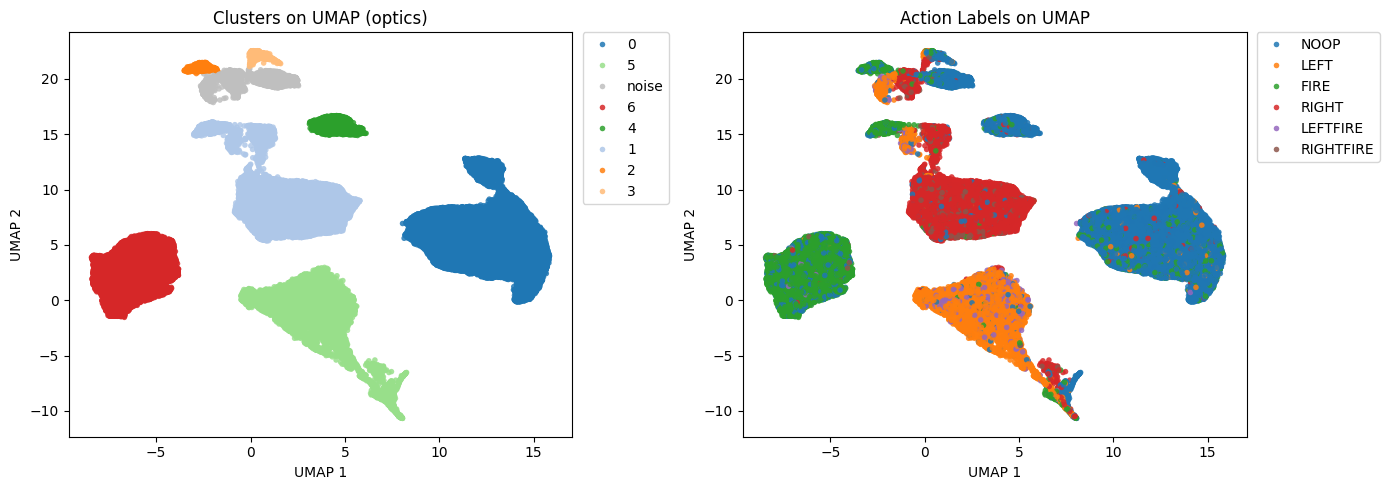

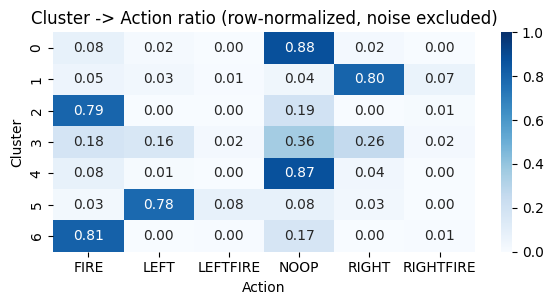

n_points                  53583.000000
n_clusters_ex_noise           7.000000
noise_ratio                   0.052890
silhouette_ex_noise           0.579615
ARI_vs_action                 0.581085
NMI_vs_action                 0.542907
homogeneity_vs_action         0.555619
completeness_vs_action        0.530763
cluster_purity                0.821277
dtype: float64


action,FIRE,LEFT,LEFTFIRE,NOOP,RIGHT,RIGHTFIRE
cluster,,,,,,
0,0.08,0.02,0.00,0.88,0.02,0.00
1,0.05,0.03,0.01,0.04,0.80,0.07
2,0.79,0.00,0.00,0.19,0.00,0.01
3,0.18,0.16,0.02,0.36,0.26,0.02
4,0.08,0.01,0.00,0.87,0.04,0.00
5,0.03,0.78,0.08,0.08,0.03,0.00
6,0.81,0.00,0.00,0.17,0.00,0.01


In [33]:
cluster_out = cluster_and_visualize_umap_space(
    umap_results_multi,
    method="optics",      # 경계가 비선형이면 optics/hdbscan이 보통 유리
    min_samples=10,
    min_cluster_size=300,
    xi=0.25,
    scale_for_cluster=True,
)
cluster_out["ct_ratio"].round(2)

cluster의 metric 계산

Matched rows: 50749 / 53583 (unmatched=0)
Cluster counts: {0: 17125, 1: 12834, 2: 590, 3: 590, 4: 1428, 5: 9729, 6: 8453}

Env return quick stats:
count    50749.000000
mean         0.168969
std          2.214088
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        200.000000
Name: env_return, dtype: float64


/tmp/ipykernel_737463/2582773551.py:490: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_names, showfliers=False)
/tmp/ipykernel_737463/2582773551.py:490: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_names, showfliers=False)
/tmp/ipykernel_737463/2582773551.py:490: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_names, showfliers=False)
/tmp/ipykernel_737463/2582773551.py:490: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old n

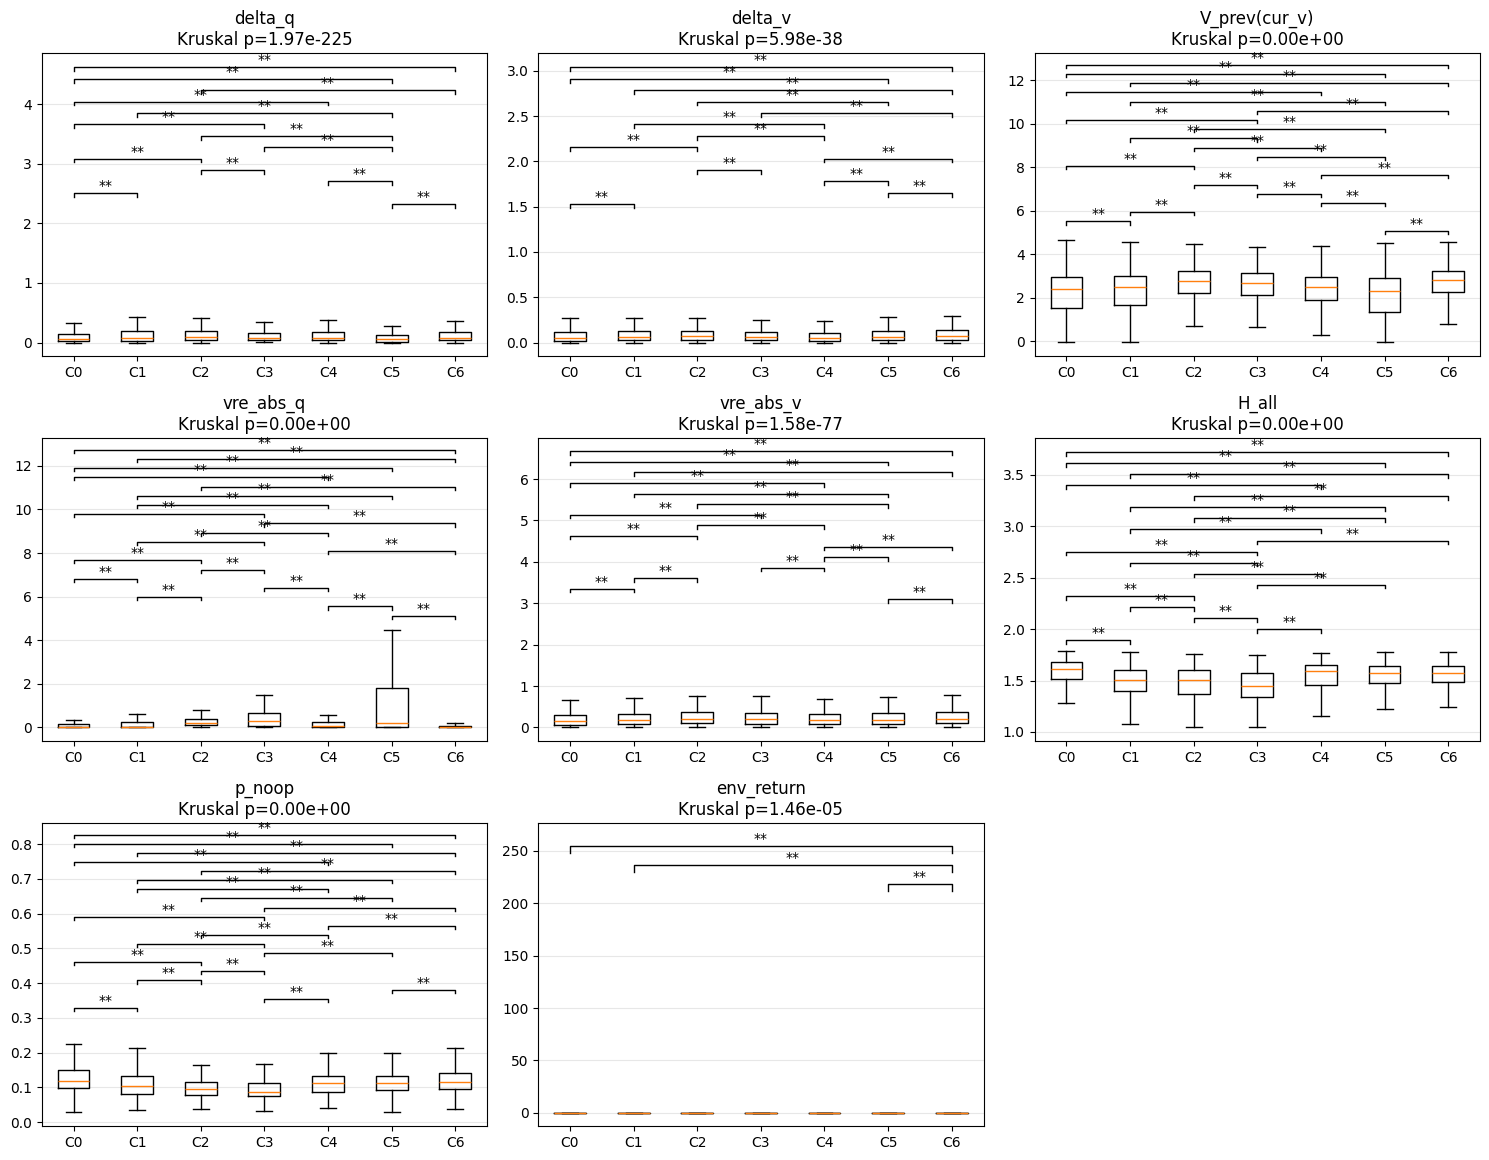

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# =========================
# 설정
# =========================
FRAGMENT_STATUSES = (1, 2)
BOX_COLS = [
    "delta_q",
    "delta_v",
    "V_prev(cur_v)",
    "vre_abs_q",
    "vre_abs_v",
    "H_all",
    "p_noop",
]
ANALYZE_COLS = BOX_COLS + ["env_return"]
SIG_ALPHA = 0.05
SIG_CORRECTION = "fdr_bh"   # 'bonferroni', 'holm', 'fdr_bh'
SHOW_NS_IN_BOX = False
PRINT_PAIRWISE_P_TABLE = True


# =========================
# 로더
# =========================
def _load_single_npy_local(path):
    if "_load_single_npy" in globals():
        return _load_single_npy(path)
    obj = np.load(str(path), allow_pickle=True)

    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.shape == ():
        d = obj.item()
        if isinstance(d, dict):
            return d

    if hasattr(obj, "files"):
        return {k: obj[k] for k in obj.files}

    raise ValueError(f"{path}: dict npy/npz를 해석할 수 없습니다.")


# =========================
# 유틸
# =========================
def to_action_ids(x):
    arr = np.asarray(x)
    if arr.ndim == 1:
        return arr.astype(int)
    return np.argmax(arr, axis=1).astype(int)

def prev_index_of_status(status_idx, ref_idx):
    if len(status_idx) == 0:
        return np.full(len(ref_idx), -1, dtype=int)
    pos = np.searchsorted(status_idx, ref_idx) - 1
    return np.where(pos >= 0, status_idx[pos], -1)

def top2_gap_1d(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 2:
        return np.nan
    part = np.partition(vals, -2)[-2:]
    return float(part.max() - part.min())

def split_contiguous(indices_1d):
    indices_1d = np.asarray(indices_1d)
    if indices_1d.size == 0:
        return []
    cuts = np.where(np.diff(indices_1d) != 1)[0] + 1
    return np.split(indices_1d, cuts)

def cluster_label(cid):
    return "Noise" if cid == -1 else f"C{cid}"

def _safe_softmax_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.size == 0:
        return np.array([1.0], dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = x - np.max(x)
    ex = np.exp(np.clip(x, -60, 60))
    s = ex.sum()
    if (not np.isfinite(s)) or (s <= 0):
        return np.full(x.size, 1.0 / x.size, dtype=float)
    return ex / s

def _pick_valid_action(a, q_ref):
    try:
        ai = int(a)
    except Exception:
        ai = -1
    if 0 <= ai < len(q_ref):
        return ai

    q = np.asarray(q_ref, dtype=float)
    q = np.where(np.isfinite(q), q, -np.inf)
    if q.size == 0 or not np.isfinite(np.max(q)):
        return 0
    return int(np.argmax(q))

def _to_1d_first_col(x):
    arr = np.asarray(x)
    if arr.ndim == 1:
        y = arr
    else:
        y = arr.reshape(arr.shape[0], -1)[:, 0]
    return pd.to_numeric(pd.Series(y), errors="coerce").to_numpy(dtype=float)

def _align_step_reward_to_real_steps(data, real_all):
    # 1) 즉시 보상 우선
    y = _to_1d_first_col(data["env_return"])
    out = np.full(len(real_all), np.nan, dtype=float)
    valid = (real_all >= 0) & (real_all < len(y))
    out[valid] = y[real_all[valid]]
    return out


# =========================
# 각 real step 지표 계산
# =========================
def build_df_real_steps_metrics(data, fragment_statuses=(1, 2), force_fill=True):
    tree = data["tree_reps"]

    status = np.asarray(data["status"]).reshape(-1)
    q_all = np.asarray(tree["cur_qs_mean"], dtype=float)
    if q_all.ndim == 1:
        q_all = q_all[:, None]
    v_all = np.asarray(tree["cur_v"], dtype=float).reshape(-1)

    root_qs = np.asarray(tree["root_qs_mean"], dtype=float) if "root_qs_mean" in tree else None
    if root_qs is not None and root_qs.ndim == 1:
        root_qs = root_qs[:, None]
    root_v_all = np.asarray(tree["root_v"], dtype=float).reshape(-1) if "root_v" in tree else None

    human_action_raw = data.get("human_action", None)
    if human_action_raw is None:
        raise ValueError("human_action not found")
    human_action_ids = to_action_ids(human_action_raw)

    actor_policy = data.get("actor_policy", None)
    if actor_policy is None:
        logits_all = None
    else:
        actor_policy = np.asarray(actor_policy)
        if actor_policy.ndim >= 2:
            logits_all = actor_policy.reshape(actor_policy.shape[0], -1)
        else:
            logits_all = actor_policy.reshape(-1, 1)

    num_actions = q_all.shape[1]

    if "cur_action" in tree:
        cur_action = np.asarray(tree["cur_action"])
        if cur_action.ndim == 2 and cur_action.shape[1] == num_actions:
            cur_action_id = np.argmax(cur_action, axis=1).astype(int)
        else:
            cur_action_id = cur_action.reshape(-1).astype(int)
    else:
        cur_action_id = np.argmax(q_all, axis=1).astype(int)

    lengths = [len(status), q_all.shape[0], len(v_all), len(human_action_ids), len(cur_action_id)]
    if root_qs is not None:
        lengths.append(root_qs.shape[0])
    if root_v_all is not None:
        lengths.append(len(root_v_all))
    if logits_all is not None:
        lengths.append(logits_all.shape[0])

    T = min(lengths)
    status = status[:T]
    q_all = q_all[:T]
    v_all = v_all[:T]
    human_action_ids = human_action_ids[:T]
    cur_action_id = cur_action_id[:T]
    if root_qs is not None:
        root_qs = root_qs[:T]
    if root_v_all is not None:
        root_v_all = root_v_all[:T]
    if logits_all is not None:
        logits_all = logits_all[:T]

    real_all = np.where(status == 0)[0]
    if len(real_all) == 0:
        return pd.DataFrame(columns=BOX_COLS + ["env_return", "real_idx", "prev_s2_idx", "human_action", "used_action"])

    # env_return을 real-step 기준으로 정렬
    env_return_real = _align_step_reward_to_real_steps(data, real_all)

    s2_indices = np.where(status == 2)[0]
    prev_s2_all = prev_index_of_status(s2_indices, real_all)
    prev_s2_fallback = np.maximum(real_all - 1, 0)
    prev_s2_all = np.where(prev_s2_all >= 0, prev_s2_all, prev_s2_fallback).astype(int)

    n_rows = len(real_all)
    delta_q = np.full(n_rows, np.nan, dtype=float)
    delta_v = np.full(n_rows, np.nan, dtype=float)
    V_prev = np.full(n_rows, np.nan, dtype=float)
    vre_abs_q = np.full(n_rows, np.nan, dtype=float)
    vre_abs_v = np.full(n_rows, np.nan, dtype=float)
    H_all = np.full(n_rows, np.nan, dtype=float)
    p_noop = np.full(n_rows, np.nan, dtype=float)
    env_return = np.full(n_rows, np.nan, dtype=float)

    human_out = np.full(n_rows, -1, dtype=int)
    used_action = np.full(n_rows, -1, dtype=int)

    for i, curr_real_idx in enumerate(real_all):
        env_return[i] = float(env_return_real[i]) if i < len(env_return_real) else np.nan

        prev_real_idx = real_all[i - 1] if i > 0 else -1
        prev_s2 = int(prev_s2_all[i])

        raw_a = int(human_action_ids[curr_real_idx]) if curr_real_idx < len(human_action_ids) else -1
        human_out[i] = raw_a if 0 <= raw_a < num_actions else -1
        target_action = human_out[i]

        between = np.arange(prev_real_idx + 1, curr_real_idx, dtype=int)
        imag_idx = between[np.isin(status[between], fragment_statuses)] if between.size > 0 else np.array([], dtype=int)

        if imag_idx.size > 0:
            if 0 <= target_action < num_actions:
                frags = split_contiguous(imag_idx)
                matched = [frag for frag in frags if frag.size > 0 and cur_action_id[frag[0]] == target_action]
                sel_idx = np.concatenate(matched) if len(matched) > 0 else imag_idx
            else:
                sel_idx = imag_idx
        else:
            sel_idx = np.array([prev_s2], dtype=int)

        sel_idx = sel_idx[(sel_idx >= 0) & (sel_idx < T)]
        if sel_idx.size == 0:
            sel_idx = np.array([min(max(curr_real_idx - 1, 0), T - 1)], dtype=int)

        q_prev = np.nanmean(q_all[sel_idx], axis=0)
        if np.any(~np.isfinite(q_prev)):
            q_fb = q_all[prev_s2] if 0 <= prev_s2 < T else q_all[min(curr_real_idx, T - 1)]
            q_prev = np.where(np.isfinite(q_prev), q_prev, q_fb)

        v_prev = float(np.nanmean(v_all[sel_idx]))
        if not np.isfinite(v_prev):
            v_prev = float(v_all[prev_s2] if 0 <= prev_s2 < T else v_all[min(curr_real_idx, T - 1)])

        a = _pick_valid_action(target_action, q_prev)
        used_action[i] = a

        delta_q[i] = top2_gap_1d(q_prev)
        V_prev[i] = v_prev

        action_means = []
        for aa in range(num_actions):
            idx_a = sel_idx[cur_action_id[sel_idx] == aa]
            if idx_a.size > 0:
                action_means.append(np.nanmean(v_all[idx_a]))

        if len(action_means) >= 2:
            delta_v[i] = top2_gap_1d(np.asarray(action_means, dtype=float))
        else:
            vv = v_all[sel_idx]
            delta_v[i] = float(np.nanmax(vv) - np.nanmin(vv)) if np.any(np.isfinite(vv)) else 0.0

        if logits_all is not None and prev_s2 < logits_all.shape[0]:
            p = _safe_softmax_1d(logits_all[prev_s2])
        elif "root_policy" in tree:
            rp = np.asarray(tree["root_policy"])
            if rp.ndim == 1:
                p = _safe_softmax_1d(rp)
            else:
                ridx = min(curr_real_idx, rp.shape[0] - 1)
                p = _safe_softmax_1d(rp[ridx])
        else:
            p = _safe_softmax_1d(q_prev)

        H_all[i] = float(-np.sum(p * np.log(p + 1e-12)))
        p_noop[i] = float(p[0]) if p.size > 0 else 0.0

        nr = real_all[i + 1] if i + 1 < len(real_all) else curr_real_idx
        if root_qs is not None and nr < root_qs.shape[0] and a < root_qs.shape[1]:
            q_ref = root_qs[nr, a]
        else:
            q_ref = q_all[min(nr, T - 1), a]
        if not np.isfinite(q_ref):
            q_ref = q_all[min(curr_real_idx, T - 1), a]
        vre_abs_q[i] = abs(float(q_prev[a]) - float(q_ref))

        if root_v_all is not None and curr_real_idx < len(root_v_all) and np.isfinite(root_v_all[curr_real_idx]):
            v_ref = float(root_v_all[curr_real_idx])
        else:
            v_ref = float(v_all[min(curr_real_idx, T - 1)])
        vre_abs_v[i] = abs(v_prev - v_ref)

    df = pd.DataFrame({
        "delta_q": delta_q,
        "delta_v": delta_v,
        "V_prev(cur_v)": V_prev,
        "vre_abs_q": vre_abs_q,
        "vre_abs_v": vre_abs_v,
        "H_all": H_all,
        "p_noop": p_noop,
        "env_return": env_return,
        "real_idx": real_all,
        "prev_s2_idx": prev_s2_all,
        "human_action": human_out,
        "used_action": used_action,
    })

    if force_fill:
        for c in BOX_COLS:  # env_return은 raw 유지
            arr = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
            arr[np.isinf(arr)] = np.nan
            fill = float(np.nanmedian(arr)) if np.any(np.isfinite(arr)) else 0.0
            arr = np.where(np.isfinite(arr), arr, fill)
            df[c] = arr

    return df


# =========================
# cluster 라벨 + 지표 결합
# =========================
def build_cluster_metric_table(cluster_out, umap_results, fragment_statuses=(1, 2), include_noise=False):
    cluster_arr = np.asarray(cluster_out["df"]["cluster"]).astype(int)
    src_arr = np.asarray(umap_results["source_file"])

    if "action_idx_local" in umap_results:
        real_idx_arr = np.asarray(umap_results["action_idx_local"]).astype(int)
    elif "real_idx" in umap_results:
        real_idx_arr = np.asarray(umap_results["real_idx"]).astype(int)
    else:
        raise ValueError("umap_results에 real index 컬럼(action_idx_local or real_idx)이 없습니다.")

    if not (len(cluster_arr) == len(src_arr) == len(real_idx_arr)):
        raise ValueError("cluster_out와 umap_results 길이가 맞지 않습니다.")

    metric_map = {}
    for f in np.unique(src_arr):
        data = _load_single_npy_local(f)
        mdf = build_df_real_steps_metrics(data, fragment_statuses=fragment_statuses, force_fill=True)
        metric_map[str(f)] = mdf.drop_duplicates(subset=["real_idx"]).set_index("real_idx")

    rows = []
    miss = 0
    for i, (f, rid, cid) in enumerate(zip(src_arr, real_idx_arr, cluster_arr)):
        if (not include_noise) and cid == -1:
            continue
        f = str(f)
        mdf = metric_map[f]
        if rid not in mdf.index:
            miss += 1
            continue
        row = mdf.loc[rid]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        out = row.to_dict()
        out["real_idx"] = int(rid)
        out["cluster"] = int(cid)
        out["source_file"] = f
        out["umap_row"] = int(i)
        rows.append(out)

    out_df = pd.DataFrame(rows)
    if out_df.empty:
        raise RuntimeError("클러스터-지표 매핑 결과가 비어 있습니다.")

    print(f"Matched rows: {len(out_df)} / {len(cluster_arr)} (unmatched={miss})")
    print("Cluster counts:", out_df["cluster"].value_counts().sort_index().to_dict())
    return out_df


# =========================
# 통계/별표
# =========================
def safe_kruskal(groups):
    if len(groups) < 2:
        return np.nan
    try:
        return float(kruskal(*groups).pvalue)
    except Exception:
        return np.nan

def pairwise_mwu_with_correction(groups, group_names, alpha=0.05, method="fdr_bh"):
    pairs = list(combinations(range(len(groups)), 2))
    raw_ps, valid_pairs = [], []

    for i, j in pairs:
        x, y = groups[i], groups[j]
        if len(x) == 0 or len(y) == 0:
            continue
        try:
            p = mannwhitneyu(x, y, alternative="two-sided").pvalue
        except Exception:
            p = 1.0
        valid_pairs.append((i, j))
        raw_ps.append(p)

    if len(raw_ps) == 0:
        return []

    _, p_adj, _, _ = multipletests(raw_ps, alpha=alpha, method=method)

    out = []
    for (i, j), p_raw, p_corr in zip(valid_pairs, raw_ps, p_adj):
        out.append({
            "i": i,
            "j": j,
            "name_i": group_names[i],
            "name_j": group_names[j],
            "p_raw": float(p_raw),
            "p_adj": float(p_corr),
            "sig": bool(p_corr < alpha),
            "mark": "**" if p_corr < alpha else "ns",
        })
    return out

def annotate_pairwise_double_star(ax, groups, pairwise_results, show_ns=False):
    finite_groups = [g[np.isfinite(g)] for g in groups if len(g) > 0]
    if len(finite_groups) == 0:
        return

    y_max = max(np.max(g) for g in finite_groups)
    y_min = min(np.min(g) for g in finite_groups)
    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = max(abs(y_max), 1.0)

    h = 0.03 * y_range
    step = 0.09 * y_range
    y = y_max + 0.06 * y_range

    draw_targets = [r for r in pairwise_results if r["sig"] or show_ns]
    draw_targets = sorted(draw_targets, key=lambda d: (d["j"] - d["i"], d["p_adj"]))

    for r in draw_targets:
        x1, x2 = r["i"] + 1, r["j"] + 1
        label = r["mark"] if r["sig"] else "ns"
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, c="k")
        ax.text((x1 + x2) / 2, y + h, label, ha="center", va="bottom", fontsize=10)
        y += step

    if len(draw_targets) > 0:
        ax.set_ylim(top=y + 0.05 * y_range)


def plot_cluster_box_stats(
    df_cluster_metrics,
    use_cols=BOX_COLS,
    alpha=0.05,
    correction="fdr_bh",
    show_ns=False,
    print_pairwise=True,
):
    use_cols = [c for c in use_cols if c in df_cluster_metrics.columns]
    if len(use_cols) == 0:
        print("사용 가능한 지표 컬럼이 없습니다.")
        return {}

    cluster_ids = sorted(df_cluster_metrics["cluster"].dropna().astype(int).unique().tolist())
    if len(cluster_ids) == 0:
        print("분석 가능한 클러스터가 없습니다.")
        return {}

    n = len(use_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.9 * nrows))
    axes = np.array(axes).reshape(-1)

    pairwise_tables = {}

    for i, col in enumerate(use_cols):
        ax = axes[i]
        group_data, group_names = [], []

        for cid in cluster_ids:
            vals = df_cluster_metrics.loc[df_cluster_metrics["cluster"] == cid, col].to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            if len(vals) > 0:
                group_data.append(vals)
                group_names.append(cluster_label(cid))

        if len(group_data) < 2:
            ax.axis("off")
            continue

        ax.boxplot(group_data, labels=group_names, showfliers=False)
        ax.grid(axis="y", alpha=0.3)

        g_p = safe_kruskal(group_data)
        ax.set_title(f"{col}\nKruskal p={g_p:.2e}" if np.isfinite(g_p) else col)

        pairwise_res = pairwise_mwu_with_correction(
            groups=group_data,
            group_names=group_names,
            alpha=alpha,
            method=correction,
        )
        annotate_pairwise_double_star(ax, group_data, pairwise_res, show_ns=show_ns)
        pairwise_tables[col] = pd.DataFrame(pairwise_res)

        #if print_pairwise:
        #    print(f"\n[{col}] pairwise MWU ({correction}, alpha={alpha})")
        #    if len(pairwise_res) == 0:
        #        print(" - no valid pairs")
        #    else:
        #        for r in pairwise_res:
        #            tag = "sig **" if r["sig"] else "ns"
        #            print(
        #                f" - {r['name_i']} vs {r['name_j']}: "
        #                f"p_raw={r['p_raw']:.3e}, p_adj={r['p_adj']:.3e}, {tag}"
        #            )

    for ax in axes[len(use_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return pairwise_tables


# =========================
# 실행
# =========================
df_cluster_metrics = build_cluster_metric_table(
    cluster_out=cluster_out,
    umap_results=umap_results_multi,
    fragment_statuses=FRAGMENT_STATUSES,
    include_noise=False,
)
print("\nEnv return quick stats:")
print(df_cluster_metrics["env_return"].describe())

pairwise_tables = plot_cluster_box_stats(
    df_cluster_metrics,
    use_cols=ANALYZE_COLS,
    alpha=SIG_ALPHA,
    correction=SIG_CORRECTION,
    show_ns=SHOW_NS_IN_BOX,
    print_pairwise=PRINT_PAIRWISE_P_TABLE,
)


In [26]:
top = df_cluster_metrics.nlargest(10, "env_return")[["source_file", "real_idx", "env_return"]]
display(top)

for _, r in top.iterrows():
    f = str(r["source_file"])
    rid = int(r["real_idx"])
    data = _load_single_npy_local(f)
    arr = np.asarray(data["env_return"])
    y = arr if arr.ndim == 1 else arr.reshape(arr.shape[0], -1)[:, 0]
    direct = float(y[rid]) if 0 <= rid < len(y) else np.nan
    print(f, rid, "stored=", float(r["env_return"]), "direct=", direct)


,source_file,real_idx,env_return
33363,test/sub001/ses-04/sub001-ses04-block4-game2_0...,696513,10140.0
33364,test/sub001/ses-04/sub001-ses04-block4-game2_0...,696584,10140.0
33365,test/sub001/ses-04/sub001-ses04-block4-game2_0...,696733,10140.0
33366,test/sub001/ses-04/sub001-ses04-block4-game2_0...,696880,10140.0
33367,test/sub001/ses-04/sub001-ses04-block4-game2_0...,698659,10140.0
33368,test/sub001/ses-04/sub001-ses04-block4-game2_0...,698735,10140.0
33369,test/sub001/ses-04/sub001-ses04-block4-game2_0...,698811,10140.0
33370,test/sub001/ses-04/sub001-ses04-block4-game2_0...,698888,10140.0
33371,test/sub001/ses-04/sub001-ses04-block4-game2_0...,698963,10140.0
33372,test/sub001/ses-04/sub001-ses04-block4-game2_0...,699040,10140.0


test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 696513 stored= 10140.0 direct= 10140.0
test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 696584 stored= 10140.0 direct= 10140.0
test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 696733 stored= 10140.0 direct= 10140.0
test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 696880 stored= 10140.0 direct= 10140.0
test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 698659 stored= 10140.0 direct= 10140.0
test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 698735 stored= 10140.0 direct= 10140.0
test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 698811 stored= 10140.0 direct= 10140.0
test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 698888 stored= 10140.0 direct= 10140.0
test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 698963 stored= 10140.0 direct= 10140.0
test/sub001/ses-04/sub001-ses04-block4-game2_001.npy 699040 stored= 10140.0 direct= 10140.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# =========================
# 설정
# =========================
FRAGMENT_STATUSES = (1, 2)
BOX_COLS = [
    "delta_q",
    "delta_v",
    "V_prev(cur_v)",
    "vre_abs_q",
    "vre_abs_v",
    "H_all",
    "p_noop",
]
SIG_ALPHA = 0.05
SIG_CORRECTION = "fdr_bh"   # 'bonferroni', 'holm', 'fdr_bh'
SHOW_NS_IN_BOX = False
PRINT_PAIRWISE_P_TABLE = True


# =========================
# 로더
# =========================
def _load_single_npy_local(path):
    if "_load_single_npy" in globals():
        return _load_single_npy(path)
    obj = np.load(str(path), allow_pickle=True)

    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.shape == ():
        d = obj.item()
        if isinstance(d, dict):
            return d

    if hasattr(obj, "files"):
        return {k: obj[k] for k in obj.files}

    raise ValueError(f"{path}: dict npy/npz를 해석할 수 없습니다.")


# =========================
# 유틸
# =========================
def to_action_ids(x):
    arr = np.asarray(x)
    if arr.ndim == 1:
        return arr.astype(int)
    return np.argmax(arr, axis=1).astype(int)

def prev_index_of_status(status_idx, ref_idx):
    if len(status_idx) == 0:
        return np.full(len(ref_idx), -1, dtype=int)
    pos = np.searchsorted(status_idx, ref_idx) - 1
    return np.where(pos >= 0, status_idx[pos], -1)

def top2_gap_1d(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 2:
        return np.nan
    part = np.partition(vals, -2)[-2:]
    return float(part.max() - part.min())

def split_contiguous(indices_1d):
    indices_1d = np.asarray(indices_1d)
    if indices_1d.size == 0:
        return []
    cuts = np.where(np.diff(indices_1d) != 1)[0] + 1
    return np.split(indices_1d, cuts)

def cluster_label(cid):
    return "Noise" if cid == -1 else f"C{cid}"

def _safe_softmax_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.size == 0:
        return np.array([1.0], dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    x = x - np.max(x)
    ex = np.exp(np.clip(x, -60, 60))
    s = ex.sum()
    if (not np.isfinite(s)) or (s <= 0):
        return np.full(x.size, 1.0 / x.size, dtype=float)
    return ex / s

def _pick_valid_action(a, q_ref):
    try:
        ai = int(a)
    except Exception:
        ai = -1
    if 0 <= ai < len(q_ref):
        return ai

    q = np.asarray(q_ref, dtype=float)
    q = np.where(np.isfinite(q), q, -np.inf)
    if q.size == 0 or not np.isfinite(np.max(q)):
        return 0
    return int(np.argmax(q))


# =========================
# 각 real step 지표 계산 (항상 값 생성)
# =========================
def build_df_real_steps_metrics(data, fragment_statuses=(1, 2), force_fill=True):
    tree = data["tree_reps"]

    status = np.asarray(data["status"]).reshape(-1)
    q_all = np.asarray(tree["cur_qs_mean"], dtype=float)
    if q_all.ndim == 1:
        q_all = q_all[:, None]
    v_all = np.asarray(tree["cur_v"], dtype=float).reshape(-1)

    # [추가] env return (raw)
    env_all = np.asarray(data["cur_rewards"], dtype=float).reshape(-1) if "cur_rewards" in data else None

    root_qs = np.asarray(tree["root_qs_mean"], dtype=float) if "root_qs_mean" in tree else None
    if root_qs is not None and root_qs.ndim == 1:
        root_qs = root_qs[:, None]
    root_v_all = np.asarray(tree["root_v"], dtype=float).reshape(-1) if "root_v" in tree else None

    human_action_raw = data.get("human_action", None)
    if human_action_raw is None:
        raise ValueError("human_action not found")
    human_action_ids = to_action_ids(human_action_raw)

    actor_policy = data.get("actor_policy", None)
    if actor_policy is None:
        logits_all = None
    else:
        actor_policy = np.asarray(actor_policy)
        if actor_policy.ndim >= 2:
            logits_all = actor_policy.reshape(actor_policy.shape[0], -1)
        else:
            logits_all = actor_policy.reshape(-1, 1)

    num_actions = q_all.shape[1]

    if "cur_action" in tree:
        cur_action = np.asarray(tree["cur_action"])
        if cur_action.ndim == 2 and cur_action.shape[1] == num_actions:
            cur_action_id = np.argmax(cur_action, axis=1).astype(int)
        else:
            cur_action_id = cur_action.reshape(-1).astype(int)
    else:
        cur_action_id = np.argmax(q_all, axis=1).astype(int)

    lengths = [len(status), q_all.shape[0], len(v_all), len(human_action_ids), len(cur_action_id)]
    if root_qs is not None:
        lengths.append(root_qs.shape[0])
    if root_v_all is not None:
        lengths.append(len(root_v_all))
    if logits_all is not None:
        lengths.append(logits_all.shape[0])
    if env_all is not None:  # [추가]
        lengths.append(len(env_all))

    T = min(lengths)
    status = status[:T]
    q_all = q_all[:T]
    v_all = v_all[:T]
    human_action_ids = human_action_ids[:T]
    cur_action_id = cur_action_id[:T]
    if root_qs is not None:
        root_qs = root_qs[:T]
    if root_v_all is not None:
        root_v_all = root_v_all[:T]
    if logits_all is not None:
        logits_all = logits_all[:T]
    if env_all is not None:  # [추가]
        env_all = env_all[:T]

    real_all = np.where(status == 0)[0]
    if len(real_all) == 0:
        return pd.DataFrame(columns=BOX_COLS + ["env_return", "real_idx", "prev_s2_idx", "human_action", "used_action"])

    s2_indices = np.where(status == 2)[0]
    prev_s2_all = prev_index_of_status(s2_indices, real_all)
    prev_s2_fallback = np.maximum(real_all - 1, 0)
    prev_s2_all = np.where(prev_s2_all >= 0, prev_s2_all, prev_s2_fallback).astype(int)

    n_rows = len(real_all)
    delta_q = np.full(n_rows, np.nan, dtype=float)
    delta_v = np.full(n_rows, np.nan, dtype=float)
    V_prev = np.full(n_rows, np.nan, dtype=float)
    vre_abs_q = np.full(n_rows, np.nan, dtype=float)
    vre_abs_v = np.full(n_rows, np.nan, dtype=float)
    H_all = np.full(n_rows, np.nan, dtype=float)
    p_noop = np.full(n_rows, np.nan, dtype=float)
    env_return = np.full(n_rows, np.nan, dtype=float)  # [추가]

    human_out = np.full(n_rows, -1, dtype=int)
    used_action = np.full(n_rows, -1, dtype=int)

    for i, curr_real_idx in enumerate(real_all):
        # [추가] 현재 real idx의 env_return 그대로
        if env_all is not None and 0 <= curr_real_idx < len(env_all):
            env_return[i] = float(env_all[curr_real_idx])

        prev_real_idx = real_all[i - 1] if i > 0 else -1
        prev_s2 = int(prev_s2_all[i])

        raw_a = int(human_action_ids[curr_real_idx]) if curr_real_idx < len(human_action_ids) else -1
        human_out[i] = raw_a if 0 <= raw_a < num_actions else -1
        target_action = human_out[i]

        between = np.arange(prev_real_idx + 1, curr_real_idx, dtype=int)
        imag_idx = between[np.isin(status[between], fragment_statuses)] if between.size > 0 else np.array([], dtype=int)

        if imag_idx.size > 0:
            if 0 <= target_action < num_actions:
                frags = split_contiguous(imag_idx)
                matched = [frag for frag in frags if frag.size > 0 and cur_action_id[frag[0]] == target_action]
                sel_idx = np.concatenate(matched) if len(matched) > 0 else imag_idx
            else:
                sel_idx = imag_idx
        else:
            sel_idx = np.array([prev_s2], dtype=int)

        sel_idx = sel_idx[(sel_idx >= 0) & (sel_idx < T)]
        if sel_idx.size == 0:
            sel_idx = np.array([min(max(curr_real_idx - 1, 0), T - 1)], dtype=int)

        q_prev = np.nanmean(q_all[sel_idx], axis=0)
        if np.any(~np.isfinite(q_prev)):
            q_fb = q_all[prev_s2] if 0 <= prev_s2 < T else q_all[min(curr_real_idx, T - 1)]
            q_prev = np.where(np.isfinite(q_prev), q_prev, q_fb)

        v_prev = float(np.nanmean(v_all[sel_idx]))
        if not np.isfinite(v_prev):
            v_prev = float(v_all[prev_s2] if 0 <= prev_s2 < T else v_all[min(curr_real_idx, T - 1)])

        a = _pick_valid_action(target_action, q_prev)
        used_action[i] = a

        delta_q[i] = top2_gap_1d(q_prev)
        V_prev[i] = v_prev

        action_means = []
        for aa in range(num_actions):
            idx_a = sel_idx[cur_action_id[sel_idx] == aa]
            if idx_a.size > 0:
                action_means.append(np.nanmean(v_all[idx_a]))

        if len(action_means) >= 2:
            delta_v[i] = top2_gap_1d(np.asarray(action_means, dtype=float))
        else:
            vv = v_all[sel_idx]
            delta_v[i] = float(np.nanmax(vv) - np.nanmin(vv)) if np.any(np.isfinite(vv)) else 0.0

        if logits_all is not None and prev_s2 < logits_all.shape[0]:
            p = _safe_softmax_1d(logits_all[prev_s2])
        elif "root_policy" in tree:
            rp = np.asarray(tree["root_policy"])
            if rp.ndim == 1:
                p = _safe_softmax_1d(rp)
            else:
                ridx = min(curr_real_idx, rp.shape[0] - 1)
                p = _safe_softmax_1d(rp[ridx])
        else:
            p = _safe_softmax_1d(q_prev)

        H_all[i] = float(-np.sum(p * np.log(p + 1e-12)))
        p_noop[i] = float(p[0]) if p.size > 0 else 0.0

        nr = real_all[i + 1] if i + 1 < len(real_all) else curr_real_idx
        if root_qs is not None and nr < root_qs.shape[0] and a < root_qs.shape[1]:
            q_ref = root_qs[nr, a]
        else:
            q_ref = q_all[min(nr, T - 1), a]
        if not np.isfinite(q_ref):
            q_ref = q_all[min(curr_real_idx, T - 1), a]
        vre_abs_q[i] = abs(float(q_prev[a]) - float(q_ref))

        if root_v_all is not None and curr_real_idx < len(root_v_all) and np.isfinite(root_v_all[curr_real_idx]):
            v_ref = float(root_v_all[curr_real_idx])
        else:
            v_ref = float(v_all[min(curr_real_idx, T - 1)])
        vre_abs_v[i] = abs(v_prev - v_ref)

    df = pd.DataFrame({
        "delta_q": delta_q,
        "delta_v": delta_v,
        "V_prev(cur_v)": V_prev,
        "vre_abs_q": vre_abs_q,
        "vre_abs_v": vre_abs_v,
        "H_all": H_all,
        "p_noop": p_noop,
        "env_return": env_return,  # [추가]
        "real_idx": real_all,
        "prev_s2_idx": prev_s2_all,
        "human_action": human_out,
        "used_action": used_action,
    })

    if force_fill:
        for c in BOX_COLS:  # env_return은 raw 유지하려고 fill 대상에서 제외
            arr = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
            arr[np.isinf(arr)] = np.nan
            fill = float(np.nanmedian(arr)) if np.any(np.isfinite(arr)) else 0.0
            arr = np.where(np.isfinite(arr), arr, fill)
            df[c] = arr

    return df



# =========================
# cluster 라벨 + 지표 결합
# =========================
def build_cluster_metric_table(cluster_out, umap_results, fragment_statuses=(1, 2), include_noise=False):
    cluster_arr = np.asarray(cluster_out["df"]["cluster"]).astype(int)
    src_arr = np.asarray(umap_results["source_file"])
    real_idx_arr = np.asarray(umap_results["action_idx_local"]).astype(int)

    if not (len(cluster_arr) == len(src_arr) == len(real_idx_arr)):
        raise ValueError("cluster_out와 umap_results 길이가 맞지 않습니다.")

    metric_map = {}
    for f in np.unique(src_arr):
        data = _load_single_npy_local(f)
        mdf = build_df_real_steps_metrics(data, fragment_statuses=fragment_statuses, force_fill=True)
        metric_map[str(f)] = mdf.drop_duplicates(subset=["real_idx"]).set_index("real_idx")

    rows = []
    miss = 0
    for i, (f, rid, cid) in enumerate(zip(src_arr, real_idx_arr, cluster_arr)):
        if (not include_noise) and cid == -1:
            continue
        f = str(f)
        mdf = metric_map[f]
        if rid not in mdf.index:
            miss += 1
            continue
        row = mdf.loc[rid]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        out = row.to_dict()
        out["real_idx"] = int(rid) 
        out["cluster"] = int(cid)
        out["source_file"] = f
        out["umap_row"] = int(i)
        rows.append(out)

    out_df = pd.DataFrame(rows)
    if out_df.empty:
        raise RuntimeError("클러스터-지표 매핑 결과가 비어 있습니다.")

    print(f"Matched rows: {len(out_df)} / {len(cluster_arr)} (unmatched={miss})")
    print("Cluster counts:", out_df["cluster"].value_counts().sort_index().to_dict())
    return out_df


# =========================
# 통계/별표( ** )
# =========================
def safe_kruskal(groups):
    if len(groups) < 2:
        return np.nan
    try:
        return float(kruskal(*groups).pvalue)
    except Exception:
        return np.nan

def pairwise_mwu_with_correction(groups, group_names, alpha=0.05, method="fdr_bh"):
    pairs = list(combinations(range(len(groups)), 2))
    raw_ps, valid_pairs = [], []

    for i, j in pairs:
        x, y = groups[i], groups[j]
        if len(x) == 0 or len(y) == 0:
            continue
        try:
            p = mannwhitneyu(x, y, alternative="two-sided").pvalue
        except Exception:
            p = 1.0
        valid_pairs.append((i, j))
        raw_ps.append(p)

    if len(raw_ps) == 0:
        return []

    _, p_adj, _, _ = multipletests(raw_ps, alpha=alpha, method=method)

    out = []
    for (i, j), p_raw, p_corr in zip(valid_pairs, raw_ps, p_adj):
        out.append({
            "i": i,
            "j": j,
            "name_i": group_names[i],
            "name_j": group_names[j],
            "p_raw": float(p_raw),
            "p_adj": float(p_corr),
            "sig": bool(p_corr < alpha),
            "mark": "**" if p_corr < alpha else "ns",
        })
    return out

def annotate_pairwise_double_star(ax, groups, pairwise_results, show_ns=False):
    finite_groups = [g[np.isfinite(g)] for g in groups if len(g) > 0]
    if len(finite_groups) == 0:
        return

    y_max = max(np.max(g) for g in finite_groups)
    y_min = min(np.min(g) for g in finite_groups)
    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = max(abs(y_max), 1.0)

    h = 0.03 * y_range
    step = 0.09 * y_range
    y = y_max + 0.06 * y_range

    draw_targets = [r for r in pairwise_results if r["sig"] or show_ns]
    draw_targets = sorted(draw_targets, key=lambda d: (d["j"] - d["i"], d["p_adj"]))

    for r in draw_targets:
        x1, x2 = r["i"] + 1, r["j"] + 1
        label = r["mark"] if r["sig"] else "ns"
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, c="k")
        ax.text((x1 + x2) / 2, y + h, label, ha="center", va="bottom", fontsize=10)
        y += step

    if len(draw_targets) > 0:
        ax.set_ylim(top=y + 0.05 * y_range)


def plot_cluster_box_stats(
    df_cluster_metrics,
    use_cols=BOX_COLS,
    alpha=0.05,
    correction="fdr_bh",
    show_ns=False,
    print_pairwise=True,
):
    use_cols = [c for c in use_cols if c in df_cluster_metrics.columns]
    if len(use_cols) == 0:
        print("사용 가능한 지표 컬럼이 없습니다.")
        return {}

    cluster_ids = sorted(df_cluster_metrics["cluster"].dropna().astype(int).unique().tolist())
    if len(cluster_ids) == 0:
        print("분석 가능한 클러스터가 없습니다.")
        return {}

    n = len(use_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.9 * nrows))
    axes = np.array(axes).reshape(-1)

    pairwise_tables = {}

    for i, col in enumerate(use_cols):
        ax = axes[i]
        group_data, group_names = [], []

        for cid in cluster_ids:
            vals = df_cluster_metrics.loc[df_cluster_metrics["cluster"] == cid, col].to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            if len(vals) > 0:
                group_data.append(vals)
                group_names.append(cluster_label(cid))

        if len(group_data) < 2:
            ax.axis("off")
            continue

        ax.boxplot(group_data, labels=group_names, showfliers=False)
        ax.grid(axis="y", alpha=0.3)

        g_p = safe_kruskal(group_data)
        ax.set_title(f"{col}\nKruskal p={g_p:.2e}" if np.isfinite(g_p) else col)

        pairwise_res = pairwise_mwu_with_correction(
            groups=group_data,
            group_names=group_names,
            alpha=alpha,
            method=correction,
        )
        annotate_pairwise_double_star(ax, group_data, pairwise_res, show_ns=show_ns)
        pairwise_tables[col] = pd.DataFrame(pairwise_res)

        #if print_pairwise:
        #    print(f"\n[{col}] pairwise MWU ({correction}, alpha={alpha})")
        #    if len(pairwise_res) == 0:
        #        print(" - no valid pairs")
        #    else:
        #        for r in pairwise_res:
        #            tag = "sig **" if r["sig"] else "ns"
        #            print(
        #                f" - {r['name_i']} vs {r['name_j']}: "
        #                f"p_raw={r['p_raw']:.3e}, p_adj={r['p_adj']:.3e}, {tag}"
        #            )

    for ax in axes[len(use_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return pairwise_tables


# =========================
# 실행
# =========================
df_cluster_metrics = build_cluster_metric_table(
    cluster_out=cluster_out,
    umap_results=umap_results_multi,
    fragment_statuses=FRAGMENT_STATUSES,
    include_noise=False,   # noise(-1) 포함하려면 True
)

display(df_cluster_metrics.head())
print("\nNaN count by metric:")
print(df_cluster_metrics[BOX_COLS].isna().sum())

pairwise_tables = plot_cluster_box_stats(
    df_cluster_metrics,
    use_cols=BOX_COLS,
    alpha=SIG_ALPHA,
    correction=SIG_CORRECTION,
    show_ns=SHOW_NS_IN_BOX,
    print_pairwise=PRINT_PAIRWISE_P_TABLE,
)


NOOP dominant vs non noop dominant cluster 비교

/tmp/ipykernel_737463/1629348169.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP-dominant", "Others"], showfliers=False)
/tmp/ipykernel_737463/1629348169.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP-dominant", "Others"], showfliers=False)
/tmp/ipykernel_737463/1629348169.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP-dominant", "Others"], showfliers=False)
/tmp/ipykernel_737463/1629348169.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

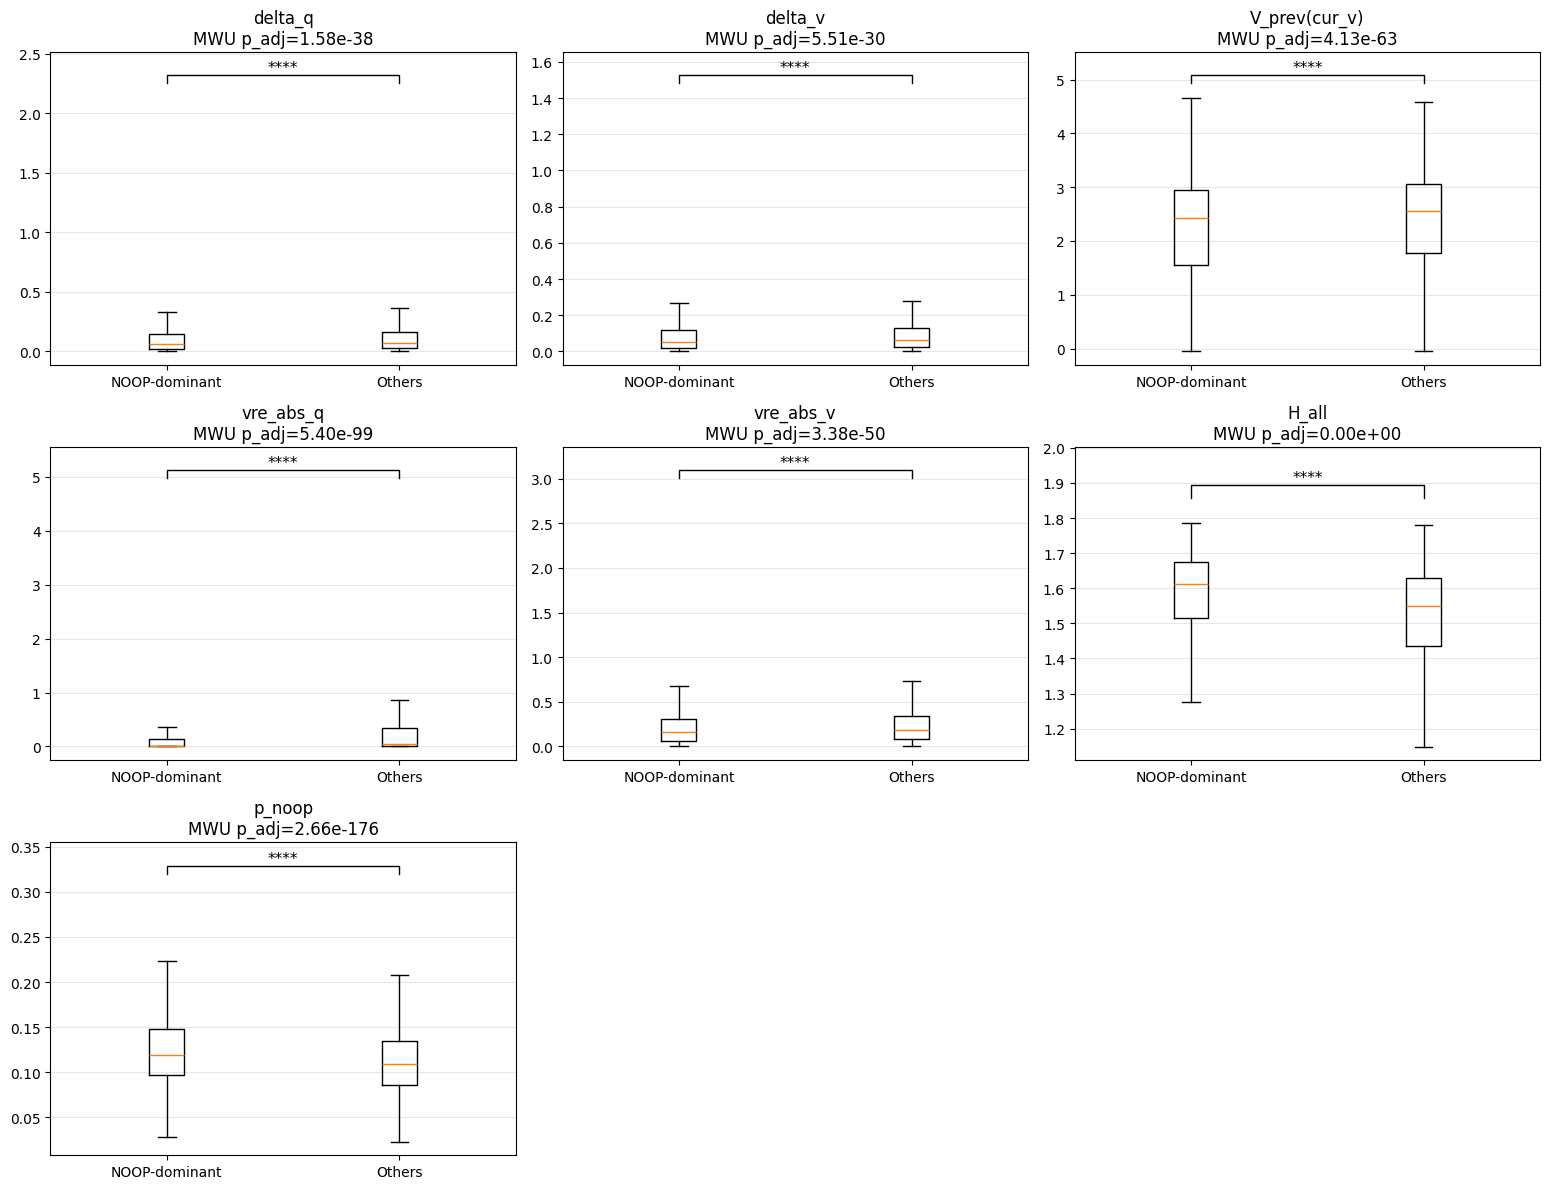

,metric,n_noop,n_others,p_raw,p_adj,mark,sig
5,H_all,18553,32196,0.000000e+00,0.000000e+00,****,True
6,p_noop,18553,32196,7.590849e-177,2.656797e-176,****,True
3,vre_abs_q,18553,32196,2.313193e-99,5.397450e-99,****,True
2,V_prev(cur_v),18553,32196,2.359257e-63,4.128700e-63,****,True
4,vre_abs_v,18553,32196,2.416090e-50,3.382527e-50,****,True
0,delta_q,18553,32196,1.357040e-38,1.583213e-38,****,True
1,delta_v,18553,32196,5.512086e-30,5.512086e-30,****,True


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# --- 1) NOOP-dominant cluster 지정 ---
# 자동 선택(예: NOOP 비율 >= 0.8)
# ct = cluster_out["ct_ratio"]
# noop_clusters = ct.index[ct["NOOP"] >= 0.8].tolist()

# 수동 지정
noop_clusters = [0,4]


def p_to_stars(p):
    """논문 관례 유의성 표기: ns, *, **, ***, ****"""
    if not np.isfinite(p):
        return "na"
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"


# --- 2) 2그룹 boxplot + 유의성(stars) ---
def plot_noop_vs_others_box(
    df_cluster_metrics,
    metrics=("delta_q", "delta_v", "V_prev(cur_v)", "vre_abs_q", "vre_abs_v", "H_all", "p_noop"),
    noop_clusters=(0, 4),
    alpha=0.05,
    correction="fdr_bh",
    show_ns=False,
):
    df = df_cluster_metrics.copy()
    df["group2"] = np.where(
        df["cluster"].isin(noop_clusters),
        "NOOP-dominant",
        "Others"
    )

    use_cols = [c for c in metrics if c in df.columns]
    if len(use_cols) == 0:
        print("사용 가능한 metric이 없습니다.")
        return pd.DataFrame()

    # p-value 계산
    test_rows = []
    for col in use_cols:
        a = pd.to_numeric(df.loc[df["group2"] == "NOOP-dominant", col], errors="coerce").dropna().values
        b = pd.to_numeric(df.loc[df["group2"] == "Others", col], errors="coerce").dropna().values

        if len(a) == 0 or len(b) == 0:
            test_rows.append({"metric": col, "n_noop": len(a), "n_others": len(b), "p_raw": np.nan})
            continue

        p = mannwhitneyu(a, b, alternative="two-sided").pvalue
        test_rows.append({"metric": col, "n_noop": len(a), "n_others": len(b), "p_raw": float(p)})

    test_df = pd.DataFrame(test_rows)

    # 다중비교 보정
    valid = test_df["p_raw"].notna().values
    p_adj = np.full(len(test_df), np.nan, dtype=float)
    if valid.sum() > 0:
        _, p_corr, _, _ = multipletests(
            test_df.loc[valid, "p_raw"].values, alpha=alpha, method=correction
        )
        p_adj[valid] = p_corr

    test_df["p_adj"] = p_adj
    test_df["mark"] = test_df["p_adj"].apply(p_to_stars)
    test_df["sig"] = test_df["mark"].isin(["*", "**", "***", "****"])

    # plot
    n = len(use_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.0 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(use_cols):
        ax = axes[i]
        a = pd.to_numeric(df.loc[df["group2"] == "NOOP-dominant", col], errors="coerce").dropna().values
        b = pd.to_numeric(df.loc[df["group2"] == "Others", col], errors="coerce").dropna().values

        if len(a) == 0 or len(b) == 0:
            ax.axis("off")
            continue

        ax.boxplot([a, b], labels=["NOOP-dominant", "Others"], showfliers=False)
        ax.grid(axis="y", alpha=0.3)

        row = test_df.loc[test_df["metric"] == col].iloc[0]
        title = f"{col}\nMWU p_adj={row['p_adj']:.2e}" if np.isfinite(row["p_adj"]) else f"{col}\nMWU p_adj=nan"
        ax.set_title(title)

        # 유의성 표시
        if np.isfinite(row["p_adj"]) and (row["mark"] != "ns" or show_ns):
            y_max = np.nanmax(np.r_[a, b])
            y_min = np.nanmin(np.r_[a, b])
            yr = y_max - y_min
            if not np.isfinite(yr) or yr <= 0:
                yr = max(abs(y_max), 1.0)

            y = y_max + 0.06 * yr
            h = 0.03 * yr
            ax.plot([1, 1, 2, 2], [y, y + h, y + h, y], c="k", lw=1.0)
            ax.text(1.5, y + h, row["mark"], ha="center", va="bottom", fontsize=11)
            ax.set_ylim(top=y + 0.12 * yr)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return test_df.sort_values("p_adj", na_position="last")


# 실행
two_group_stats = plot_noop_vs_others_box(
    df_cluster_metrics=df_cluster_metrics,
    metrics=BOX_COLS,
    noop_clusters=noop_clusters,   # [0,4]
    alpha=SIG_ALPHA,
    correction=SIG_CORRECTION,
    show_ns=False
)

display(two_group_stats)


특정 cluster만 골라서 metric 비교

/tmp/ipykernel_737463/3031243442.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=x_labels, showfliers=False)
/tmp/ipykernel_737463/3031243442.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=x_labels, showfliers=False)
/tmp/ipykernel_737463/3031243442.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=x_labels, showfliers=False)
/tmp/ipykernel_737463/3031243442.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

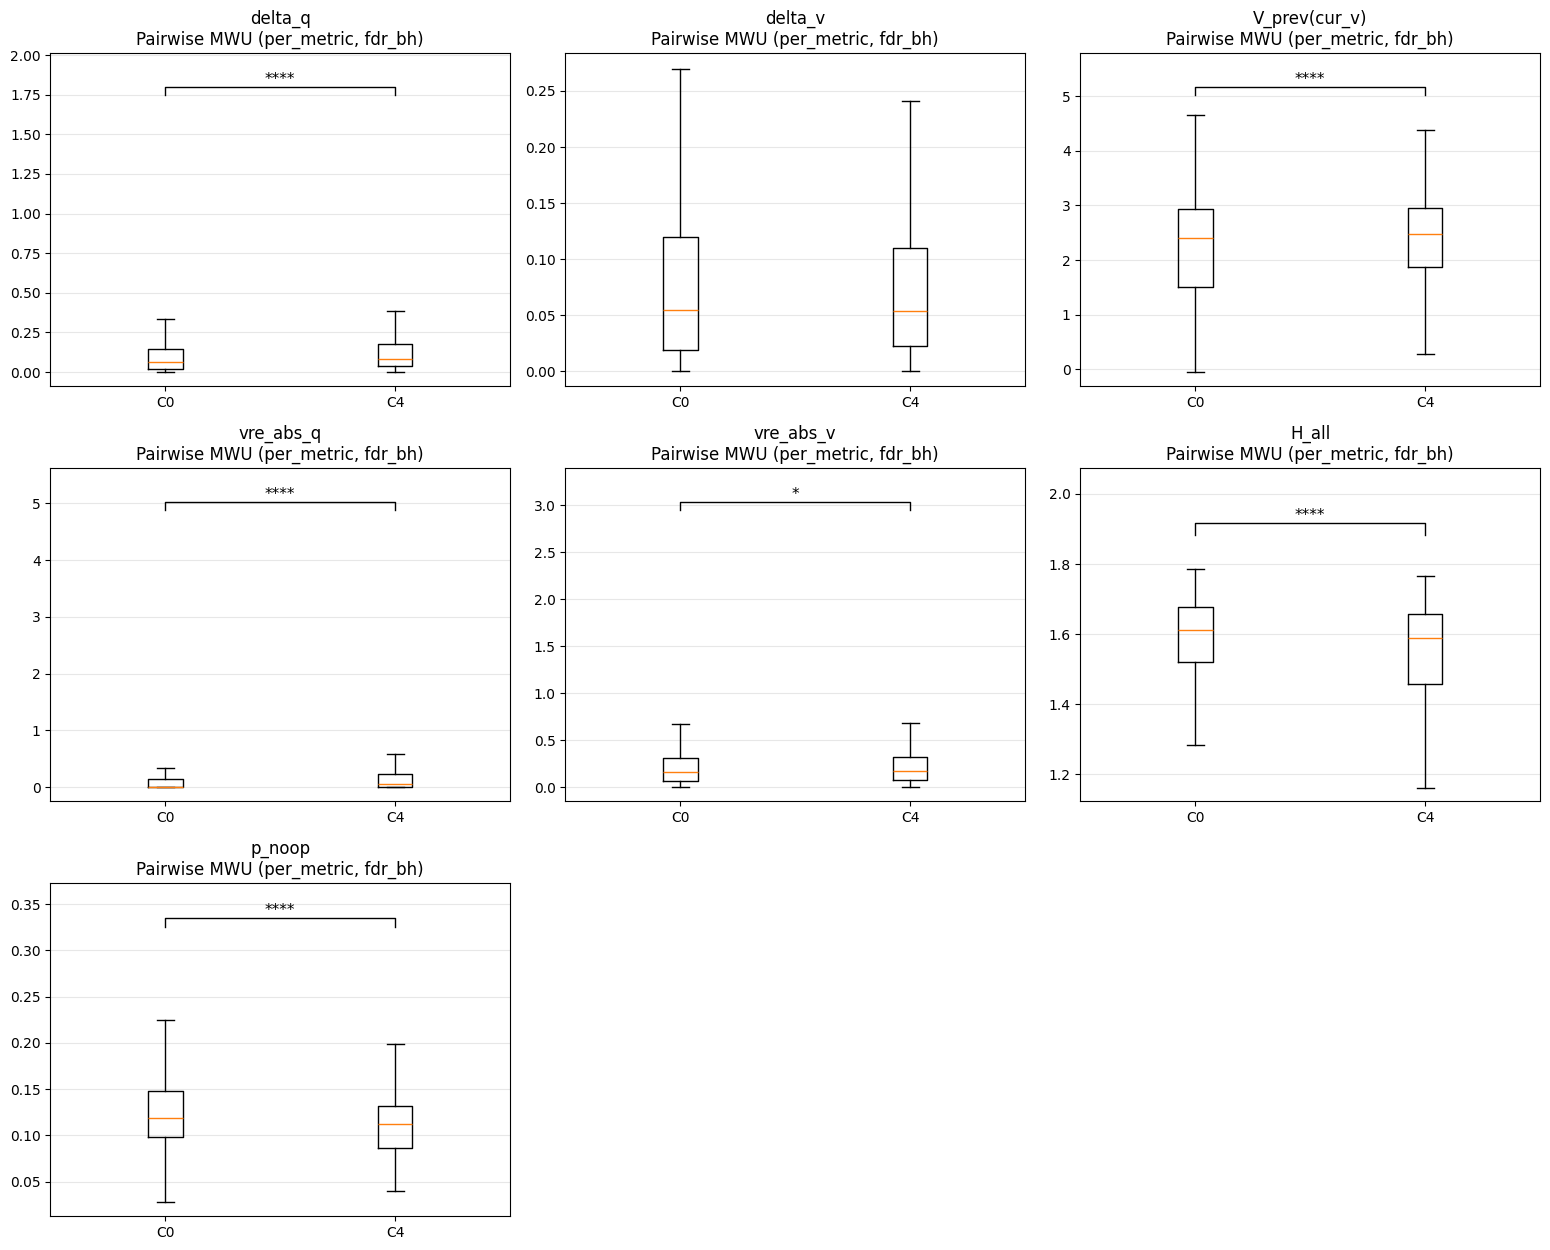

,metric,cluster_a,cluster_b,n_a,n_b,p_raw,p_adj,mark,sig
0,H_all,0,4,17125,1428,1.413039e-19,1.413039e-19,****,True
1,V_prev(cur_v),0,4,17125,1428,2.395583e-06,2.395583e-06,****,True
2,delta_q,0,4,17125,1428,8.211250e-22,8.211250e-22,****,True
3,delta_v,0,4,17125,1428,9.562706e-01,9.562706e-01,ns,False
4,p_noop,0,4,17125,1428,1.215711e-22,1.215711e-22,****,True
5,vre_abs_q,0,4,17125,1428,4.305687e-16,4.305687e-16,****,True
6,vre_abs_v,0,4,17125,1428,3.160594e-02,3.160594e-02,*,True


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


def p_to_stars(p):
    """Paper-style significance labels."""
    if not np.isfinite(p):
        return "na"
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"


def plot_clusters_pairwise_box(
    df_cluster_metrics,
    metrics=("delta_q", "delta_v", "V_prev(cur_v)", "vre_abs_q", "vre_abs_v", "H_all", "p_noop"),
    clusters=(1, 2, 3),
    alpha=0.05,
    correction="fdr_bh",
    correction_scope="per_metric",  # "per_metric" or "global"
    show_ns=False,
):
    """
    Compare specific clusters pairwise with MWU test and draw boxplots.
    Example: clusters=[1,2,3] -> 3 boxplots and pairwise tests (1-2, 1-3, 2-3).
    """
    df = df_cluster_metrics.copy()
    clusters = list(dict.fromkeys(clusters))  # keep order, remove duplicates

    if len(clusters) < 2:
        raise ValueError("`clusters` must contain at least 2 cluster IDs.")

    use_cols = [c for c in metrics if c in df.columns]
    if len(use_cols) == 0:
        print("No valid metric columns found.")
        return pd.DataFrame()

    # Cache values per metric x cluster
    values_cache = {}
    for col in use_cols:
        values_cache[col] = {}
        for c in clusters:
            arr = pd.to_numeric(
                df.loc[df["cluster"] == c, col], errors="coerce"
            ).dropna().values
            values_cache[col][c] = arr

    # Pairwise p-values
    rows = []
    for col in use_cols:
        for c1, c2 in combinations(clusters, 2):
            a = values_cache[col][c1]
            b = values_cache[col][c2]

            if len(a) == 0 or len(b) == 0:
                p_raw = np.nan
            else:
                p_raw = float(mannwhitneyu(a, b, alternative="two-sided").pvalue)

            rows.append(
                {
                    "metric": col,
                    "cluster_a": c1,
                    "cluster_b": c2,
                    "n_a": len(a),
                    "n_b": len(b),
                    "p_raw": p_raw,
                }
            )

    test_df = pd.DataFrame(rows)
    test_df["p_adj"] = np.nan

    # Multiple-testing correction
    if correction_scope == "per_metric":
        for col in use_cols:
            m = (test_df["metric"] == col) & test_df["p_raw"].notna()
            if m.sum() > 0:
                _, p_corr, _, _ = multipletests(
                    test_df.loc[m, "p_raw"].values,
                    alpha=alpha,
                    method=correction
                )
                test_df.loc[m, "p_adj"] = p_corr
    elif correction_scope == "global":
        m = test_df["p_raw"].notna()
        if m.sum() > 0:
            _, p_corr, _, _ = multipletests(
                test_df.loc[m, "p_raw"].values,
                alpha=alpha,
                method=correction
            )
            test_df.loc[m, "p_adj"] = p_corr
    else:
        raise ValueError("`correction_scope` must be 'per_metric' or 'global'.")

    test_df["mark"] = test_df["p_adj"].apply(p_to_stars)
    test_df["sig"] = test_df["mark"].isin(["*", "**", "***", "****"])

    # Plot
    n = len(use_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    x_pos = {c: i + 1 for i, c in enumerate(clusters)}
    x_labels = [f"C{c}" for c in clusters]

    for i, col in enumerate(use_cols):
        ax = axes[i]

        raw_data = [values_cache[col][c] for c in clusters]
        non_empty = [v for v in raw_data if len(v) > 0]
        if len(non_empty) < 2:
            ax.axis("off")
            continue

        # Keep x-axis positions stable even if some clusters are empty
        plot_data = [v if len(v) > 0 else np.array([np.nan]) for v in raw_data]
        ax.boxplot(plot_data, labels=x_labels, showfliers=False)
        ax.grid(axis="y", alpha=0.3)
        ax.set_title(f"{col}\nPairwise MWU ({correction_scope}, {correction})")

        pair_df = test_df[test_df["metric"] == col].copy()
        pair_df = pair_df[pair_df["p_adj"].notna()].copy()
        if not show_ns:
            pair_df = pair_df[pair_df["mark"] != "ns"].copy()

        if len(pair_df) > 0:
            all_vals = np.concatenate(non_empty)
            y_max = np.nanmax(all_vals)
            y_min = np.nanmin(all_vals)
            yr = y_max - y_min
            if not np.isfinite(yr) or yr <= 0:
                yr = max(abs(y_max), 1.0)

            pair_df["x1"] = pair_df["cluster_a"].map(x_pos)
            pair_df["x2"] = pair_df["cluster_b"].map(x_pos)
            pair_df["span"] = (pair_df["x2"] - pair_df["x1"]).abs()
            pair_df = pair_df.sort_values(["span", "p_adj"], ascending=[True, True]).reset_index(drop=True)

            base = y_max + 0.08 * yr
            step = 0.08 * yr
            h = 0.03 * yr

            for k, r in pair_df.iterrows():
                x1, x2 = int(r["x1"]), int(r["x2"])
                if x1 > x2:
                    x1, x2 = x2, x1

                y = base + k * step
                ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], c="k", lw=1.0)
                ax.text((x1 + x2) / 2, y + h, r["mark"], ha="center", va="bottom", fontsize=11)

            ax.set_ylim(top=base + (len(pair_df) + 1) * step)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return test_df.sort_values(["metric", "p_adj", "p_raw"], na_position="last").reset_index(drop=True)


# ===== Run =====
clusters = [0,4]

pairwise_stats = plot_clusters_pairwise_box(
    df_cluster_metrics=df_cluster_metrics,
    metrics=BOX_COLS,
    clusters=clusters,           # e.g., [1,2,3] => 3 boxplots
    alpha=SIG_ALPHA,
    correction=SIG_CORRECTION,
    correction_scope="per_metric",
    show_ns=False
)

display(pairwise_stats)


특정 cluster의 noop만 골라서 cluster끼리 비교

/tmp/ipykernel_737463/1858399900.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=x_labels, showfliers=False)
/tmp/ipykernel_737463/1858399900.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=x_labels, showfliers=False)
/tmp/ipykernel_737463/1858399900.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=x_labels, showfliers=False)
/tmp/ipykernel_737463/1858399900.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

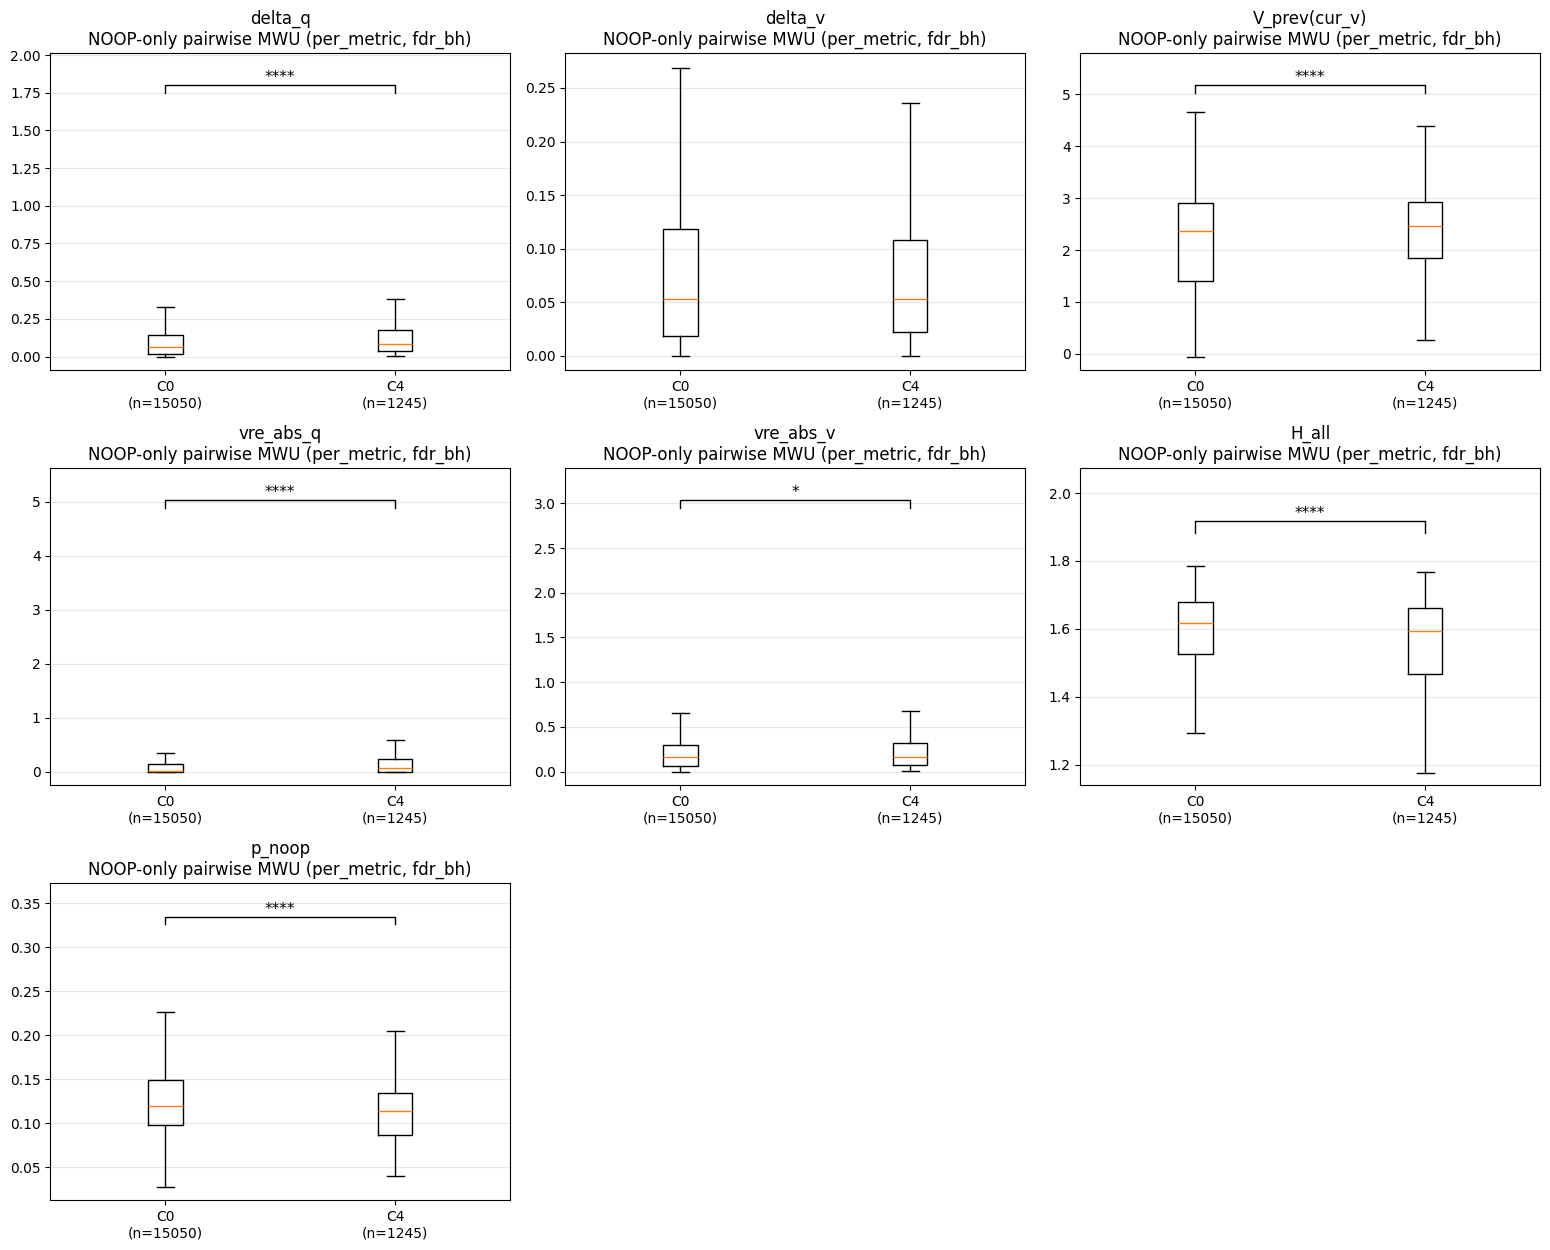

,metric,cluster_a,cluster_b,n_a,n_b,p_raw,p_adj,mark,sig
0,H_all,0,4,15050,1245,2.423104e-18,2.423104e-18,****,True
1,V_prev(cur_v),0,4,15050,1245,1.243439e-08,1.243439e-08,****,True
2,delta_q,0,4,15050,1245,7.616453e-23,7.616453e-23,****,True
3,delta_v,0,4,15050,1245,7.708620e-01,7.708620e-01,ns,False
4,p_noop,0,4,15050,1245,2.806679e-18,2.806679e-18,****,True
5,vre_abs_q,0,4,15050,1245,1.853506e-16,1.853506e-16,****,True
6,vre_abs_v,0,4,15050,1245,1.915197e-02,1.915197e-02,*,True


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


def p_to_stars(p):
    """Paper-style significance labels."""
    if not np.isfinite(p):
        return "na"
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"


def make_noop_mask(df, noop_col="action", noop_values=("NOOP",), case_insensitive=True):
    """
    Create boolean mask for NOOP rows.
    - noop_col: action label/id column name
    - noop_values: values regarded as NOOP (e.g., ("NOOP",) or (0,))
    """
    if noop_col not in df.columns:
        raise ValueError(f"`{noop_col}` column not found in df_cluster_metrics.")

    s = df[noop_col]
    if pd.api.types.is_numeric_dtype(s):
        return s.isin(noop_values)

    if case_insensitive:
        target = {str(v).strip().upper() for v in noop_values}
        return s.astype(str).str.strip().str.upper().isin(target)

    return s.isin(noop_values)


def plot_clusters_pairwise_box_noop_only(
    df_cluster_metrics,
    metrics=("delta_q", "delta_v", "V_prev(cur_v)", "vre_abs_q", "vre_abs_v", "H_all", "p_noop"),
    clusters=(1, 2, 3),
    alpha=0.05,
    correction="fdr_bh",
    correction_scope="per_metric",  # "per_metric" or "global"
    show_ns=False,
    noop_col="action",              # 실제 컬럼명으로 바꾸세요 (예: "action_name", "action_id")
    noop_values=("NOOP",),          # 실제 값으로 바꾸세요 (예: (0,), ("noop",))
    case_insensitive=True,
):
    """
    1) 지정 cluster만 선택
    2) 그 안에서 NOOP action row만 선택
    3) cluster 간 pairwise MWU + 다중비교보정
    4) metric별 boxplot + 유의성(stars) 표시
    """
    df = df_cluster_metrics.copy()
    clusters = list(dict.fromkeys(clusters))  # order 유지 + 중복 제거
    if len(clusters) < 2:
        raise ValueError("`clusters` must contain at least 2 cluster IDs.")

    if "cluster" not in df.columns:
        raise ValueError("`cluster` column not found in df_cluster_metrics.")

    # cluster + NOOP 필터
    df = df[df["cluster"].isin(clusters)].copy()
    noop_mask = make_noop_mask(
        df,
        noop_col=noop_col,
        noop_values=noop_values,
        case_insensitive=case_insensitive
    )
    df = df[noop_mask].copy()

    if df.empty:
        print("선택한 cluster 내 NOOP 데이터가 없습니다.")
        return pd.DataFrame()

    use_cols = [c for c in metrics if c in df.columns]
    if len(use_cols) == 0:
        print("No valid metric columns found.")
        return pd.DataFrame()

    # metric x cluster 값 캐시
    values_cache = {}
    for col in use_cols:
        values_cache[col] = {}
        for c in clusters:
            arr = pd.to_numeric(df.loc[df["cluster"] == c, col], errors="coerce").dropna().values
            values_cache[col][c] = arr

    # pairwise p-value 계산
    rows = []
    for col in use_cols:
        for c1, c2 in combinations(clusters, 2):
            a = values_cache[col][c1]
            b = values_cache[col][c2]

            if len(a) == 0 or len(b) == 0:
                p_raw = np.nan
            else:
                p_raw = float(mannwhitneyu(a, b, alternative="two-sided").pvalue)

            rows.append({
                "metric": col,
                "cluster_a": c1,
                "cluster_b": c2,
                "n_a": len(a),
                "n_b": len(b),
                "p_raw": p_raw,
            })

    test_df = pd.DataFrame(rows)
    test_df["p_adj"] = np.nan

    # 다중비교 보정
    if correction_scope == "per_metric":
        for col in use_cols:
            m = (test_df["metric"] == col) & test_df["p_raw"].notna()
            if m.sum() > 0:
                _, p_corr, _, _ = multipletests(
                    test_df.loc[m, "p_raw"].values,
                    alpha=alpha,
                    method=correction
                )
                test_df.loc[m, "p_adj"] = p_corr
    elif correction_scope == "global":
        m = test_df["p_raw"].notna()
        if m.sum() > 0:
            _, p_corr, _, _ = multipletests(
                test_df.loc[m, "p_raw"].values,
                alpha=alpha,
                method=correction
            )
            test_df.loc[m, "p_adj"] = p_corr
    else:
        raise ValueError("`correction_scope` must be 'per_metric' or 'global'.")

    test_df["mark"] = test_df["p_adj"].apply(p_to_stars)
    test_df["sig"] = test_df["mark"].isin(["*", "**", "***", "****"])

    # plot
    n = len(use_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    x_pos = {c: i + 1 for i, c in enumerate(clusters)}
    cluster_n = df["cluster"].value_counts().to_dict()
    x_labels = [f"C{c}\n(n={cluster_n.get(c, 0)})" for c in clusters]

    for i, col in enumerate(use_cols):
        ax = axes[i]

        raw_data = [values_cache[col][c] for c in clusters]
        non_empty = [v for v in raw_data if len(v) > 0]
        if len(non_empty) < 2:
            ax.axis("off")
            continue

        # 빈 cluster도 x축 위치는 유지
        plot_data = [v if len(v) > 0 else np.array([np.nan]) for v in raw_data]
        ax.boxplot(plot_data, labels=x_labels, showfliers=False)
        ax.grid(axis="y", alpha=0.3)
        ax.set_title(f"{col}\nNOOP-only pairwise MWU ({correction_scope}, {correction})")

        pair_df = test_df[test_df["metric"] == col].copy()
        pair_df = pair_df[pair_df["p_adj"].notna()].copy()
        if not show_ns:
            pair_df = pair_df[pair_df["mark"] != "ns"].copy()

        if len(pair_df) > 0:
            all_vals = np.concatenate(non_empty)
            y_max = np.nanmax(all_vals)
            y_min = np.nanmin(all_vals)
            yr = y_max - y_min
            if not np.isfinite(yr) or yr <= 0:
                yr = max(abs(y_max), 1.0)

            pair_df["x1"] = pair_df["cluster_a"].map(x_pos)
            pair_df["x2"] = pair_df["cluster_b"].map(x_pos)
            pair_df["span"] = (pair_df["x2"] - pair_df["x1"]).abs()
            pair_df = pair_df.sort_values(["span", "p_adj"], ascending=[True, True]).reset_index(drop=True)

            base = y_max + 0.08 * yr
            step = 0.08 * yr
            h = 0.03 * yr

            for k, r in pair_df.iterrows():
                x1, x2 = int(r["x1"]), int(r["x2"])
                if x1 > x2:
                    x1, x2 = x2, x1

                y = base + k * step
                ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], c="k", lw=1.0)
                ax.text((x1 + x2) / 2, y + h, r["mark"], ha="center", va="bottom", fontsize=11)

            ax.set_ylim(top=base + (len(pair_df) + 1) * step)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return test_df.sort_values(["metric", "p_adj", "p_raw"], na_position="last").reset_index(drop=True)


# ===== Run =====
clusters = [0,4]

pairwise_stats_noop = plot_clusters_pairwise_box_noop_only(
    df_cluster_metrics=df_cluster_metrics,
    metrics=BOX_COLS,
    clusters=clusters,
    alpha=SIG_ALPHA,
    correction=SIG_CORRECTION,
    correction_scope="per_metric",
    show_ns=False,
    noop_col="human_action",        # <- 실제 데이터 컬럼명으로 수정
    noop_values=[0],    # <- 실제 NOOP 값으로 수정 (예: (0,))
)

display(pairwise_stats_noop)


k step return 비교

Valid k_step rows: 16295 / 16295 (load/index fail=0)

Cluster-wise k_step_return_sum summary
 - C0: n=15050, mean=0.2471, med=0.1361, IQR=(0.0213, 0.3117)
 - C4: n=1245, mean=0.2594, med=0.1497, IQR=(0.0377, 0.3503)

Kruskal p = 1.691e-02

[k_step_return_sum] pairwise MWU (fdr_bh, alpha=0.05)
 - C0 vs C4: p_raw=1.691e-02, p_adj=1.691e-02, sig *


,i,j,name_i,name_j,n_i,n_j,p_raw,p_adj,stars,sig
0,0,1,C0,C4,15050,1245,0.016911,0.016911,*,True


/tmp/ipykernel_737463/1829344333.py:313: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group_data, labels=group_names, showfliers=False)


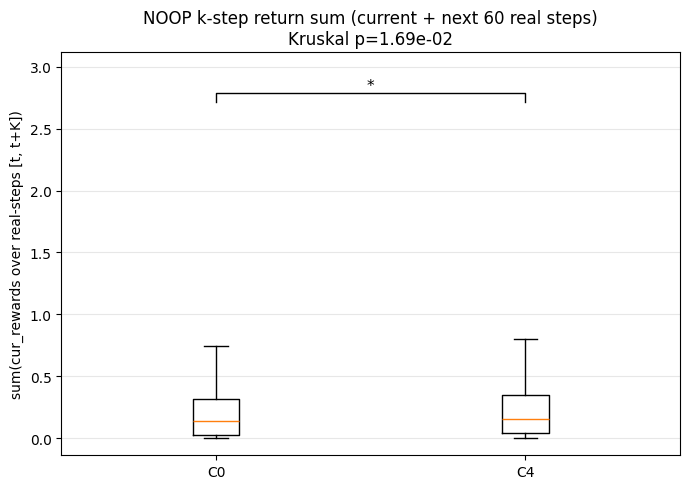

In [45]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ===== 설정 =====
K_FUTURE = 60                    # 현재 real step 포함 + 다음 K개 real step 합
NOOP_ID = 0                     # NOOP action id
TARGET_CLUSTERS = [0,4]        # None이면 전체 cluster
SIG_ALPHA = globals().get("SIG_ALPHA", 0.05)
SIG_CORRECTION = globals().get("SIG_CORRECTION", "fdr_bh")
SHOW_NS_IN_BOX = globals().get("SHOW_NS_IN_BOX", False)

if isinstance(files, tuple):
    if len(files) == 1 and isinstance(files[0], list):
        files = files[0]
    else:
        files = list(files)

# df_cluster_metrics 준비
if "df_cluster_metrics" not in globals():
    needed = ["build_cluster_metric_table", "cluster_out", "umap_results_multi"]
    miss = [k for k in needed if k not in globals()]
    if miss:
        raise NameError(f"`df_cluster_metrics`가 없고, 자동 생성에도 필요한 객체가 없습니다: {miss}")
    df_cluster_metrics = build_cluster_metric_table(
        cluster_out=cluster_out,
        umap_results=umap_results_multi,
        fragment_statuses=(1, 2),
        include_noise=False,
    )

required_cols = ["source_file", "real_idx", "cluster", "human_action"]
missing_cols = [c for c in required_cols if c not in df_cluster_metrics.columns]
if missing_cols:
    raise ValueError(f"`df_cluster_metrics`에 필요한 컬럼이 없습니다: {missing_cols}")


def p_to_stars(p):
    if not np.isfinite(p):
        return "na"
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"


def safe_kruskal(groups):
    valid = [g for g in groups if len(g) > 0]
    if len(valid) < 2:
        return np.nan
    try:
        return float(kruskal(*valid).pvalue)
    except Exception:
        return np.nan


def pairwise_mwu_with_correction(groups, group_names, alpha=0.05, method="fdr_bh"):
    rows = []
    for i, j in combinations(range(len(groups)), 2):
        a = np.asarray(groups[i], dtype=float)
        b = np.asarray(groups[j], dtype=float)
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]

        if len(a) == 0 or len(b) == 0:
            p_raw = np.nan
        else:
            p_raw = float(mannwhitneyu(a, b, alternative="two-sided").pvalue)

        rows.append({
            "i": i, "j": j,
            "name_i": group_names[i], "name_j": group_names[j],
            "n_i": len(a), "n_j": len(b),
            "p_raw": p_raw
        })

    if len(rows) == 0:
        return []

    m = np.array([np.isfinite(r["p_raw"]) for r in rows])
    if m.sum() > 0:
        _, p_adj, _, _ = multipletests(
            [rows[k]["p_raw"] for k in range(len(rows)) if m[k]],
            alpha=alpha,
            method=method
        )
        t = 0
        for k in range(len(rows)):
            rows[k]["p_adj"] = float(p_adj[t]) if m[k] else np.nan
            if m[k]:
                t += 1
    else:
        for r in rows:
            r["p_adj"] = np.nan

    for r in rows:
        r["stars"] = p_to_stars(r["p_adj"])
        r["sig"] = r["stars"] in ["*", "**", "***", "****"]

    return rows


def annotate_pairwise_stars(ax, groups, pairwise_results, show_ns=False):
    if len(pairwise_results) == 0:
        return

    valid_groups = [np.asarray(g, dtype=float) for g in groups if len(g) > 0]
    if len(valid_groups) == 0:
        return

    all_vals = np.concatenate([g[np.isfinite(g)] for g in valid_groups if np.isfinite(g).any()])
    if all_vals.size == 0:
        return

    y_max = np.nanmax(all_vals)
    y_min = np.nanmin(all_vals)
    yr = y_max - y_min
    if not np.isfinite(yr) or yr <= 0:
        yr = max(abs(y_max), 1.0)

    rows = [r for r in pairwise_results if np.isfinite(r["p_adj"])]
    if not show_ns:
        rows = [r for r in rows if r["stars"] != "ns"]
    if len(rows) == 0:
        return

    rows = sorted(rows, key=lambda r: (abs(r["j"] - r["i"]), r["p_adj"]))
    base = y_max + 0.08 * yr
    step = 0.08 * yr
    h = 0.03 * yr

    for k, r in enumerate(rows):
        x1, x2 = r["i"] + 1, r["j"] + 1
        if x1 > x2:
            x1, x2 = x2, x1
        y = base + k * step
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], c="k", lw=1.0)
        ax.text((x1 + x2) / 2, y + h, r["stars"], ha="center", va="bottom", fontsize=11)

    ax.set_ylim(top=base + (len(rows) + 1) * step)


def _load_single_npy_local(path):
    if "_load_single_npy" in globals():
        return _load_single_npy(path)

    obj = np.load(str(path), allow_pickle=True)
    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.shape == ():
        d = obj.item()
        if isinstance(d, dict):
            return d
    if hasattr(obj, "files"):
        return {k: obj[k] for k in obj.files}
    raise ValueError(f"{path}: dict npy/npz 해석 실패")


# source_file 경로 보정 맵
path_map = {}
for f in files:
    path_map[str(f)] = str(f)
    path_map[Path(f).name] = str(f)

def _resolve_path(src):
    s = str(src)
    if os.path.exists(s):
        return s
    if s in path_map:
        return path_map[s]
    b = Path(s).name
    if b in path_map:
        return path_map[b]
    return s


def _prepare_cache_one_file(path):
    data = _load_single_npy_local(path)
    status = np.asarray(data["status"]).reshape(-1)
    env = np.asarray(data["cur_rewards"], dtype=float).reshape(-1)

    T = min(len(status), len(env))
    status = status[:T]
    env = env[:T]

    real_all = np.where(status == 0)[0].astype(int)
    pos_lookup = {int(idx): int(pos) for pos, idx in enumerate(real_all)}

    return {
        "real_all": real_all,
        "env": env,
        "pos_lookup": pos_lookup,
    }


def _k_step_sum_from_cache(c, real_idx, k_future):
    pos = c["pos_lookup"].get(int(real_idx), None)
    if pos is None:
        return np.nan
    end = min(pos + k_future + 1, len(c["real_all"]))
    sel = c["real_all"][pos:end]
    if sel.size == 0:
        return np.nan
    return float(np.nansum(c["env"][sel]))


# ===== 1) NOOP + target cluster 필터 =====
df_eval = df_cluster_metrics.copy()
df_eval["cluster"] = pd.to_numeric(df_eval["cluster"], errors="coerce")
df_eval["real_idx"] = pd.to_numeric(df_eval["real_idx"], errors="coerce")
df_eval["human_action"] = pd.to_numeric(df_eval["human_action"], errors="coerce")

if TARGET_CLUSTERS is not None:
    df_eval = df_eval[df_eval["cluster"].isin(TARGET_CLUSTERS)].copy()

df_eval = df_eval[df_eval["human_action"] == NOOP_ID].copy()
df_eval = df_eval[df_eval["real_idx"].notna()].copy()

if df_eval.empty:
    raise RuntimeError("선택한 cluster/NOOP 조건에서 데이터가 없습니다.")

# ===== 2) 이 단계에서 k_step_return_sum 계산 =====
cache = {}
k_vals = []
fail_count = 0

for src, rid in zip(df_eval["source_file"].astype(str).values, df_eval["real_idx"].astype(int).values):
    p = _resolve_path(src)
    if p not in cache:
        try:
            cache[p] = _prepare_cache_one_file(p)
        except Exception:
            cache[p] = None

    c = cache[p]
    if c is None:
        k_vals.append(np.nan)
        fail_count += 1
        continue

    k_vals.append(_k_step_sum_from_cache(c, rid, K_FUTURE))

df_eval["k_step_return_sum"] = np.asarray(k_vals, dtype=float)
n_before = len(df_eval)
df_eval = df_eval[np.isfinite(df_eval["k_step_return_sum"])].copy()
print(f"Valid k_step rows: {len(df_eval)} / {n_before} (load/index fail={fail_count})")

if df_eval.empty:
    raise RuntimeError("k_step_return_sum 계산 후 유효한 데이터가 없습니다.")

# ===== 3) cluster별 통계 =====
cluster_ids = sorted(df_eval["cluster"].dropna().astype(int).unique().tolist())
group_data, group_names = [], []

for cid in cluster_ids:
    vals = pd.to_numeric(
        df_eval.loc[df_eval["cluster"] == cid, "k_step_return_sum"],
        errors="coerce"
    ).values
    vals = vals[np.isfinite(vals)]
    if len(vals) > 0:
        group_data.append(vals)
        group_names.append(f"C{cid}")

if len(group_data) == 0:
    raise RuntimeError("분석 가능한 클러스터 데이터가 없습니다.")

print("\nCluster-wise k_step_return_sum summary")
for name, arr in zip(group_names, group_data):
    q1, med, q3 = np.quantile(arr, [0.25, 0.5, 0.75])
    print(f" - {name}: n={len(arr)}, mean={np.mean(arr):.4f}, med={med:.4f}, IQR=({q1:.4f}, {q3:.4f})")

global_p = safe_kruskal(group_data)
print(f"\nKruskal p = {global_p:.3e}")

pairwise_results = pairwise_mwu_with_correction(
    groups=group_data,
    group_names=group_names,
    alpha=SIG_ALPHA,
    method=SIG_CORRECTION,
)

print(f"\n[k_step_return_sum] pairwise MWU ({SIG_CORRECTION}, alpha={SIG_ALPHA})")
if len(pairwise_results) == 0:
    print(" - no valid pairs")
else:
    for r in pairwise_results:
        print(
            f" - {r['name_i']} vs {r['name_j']}: "
            f"p_raw={r['p_raw']:.3e}, p_adj={r['p_adj']:.3e}, "
            f"{'sig' if r['sig'] else 'ns'} {r['stars']}"
        )

pairwise_df = (
    pd.DataFrame(pairwise_results).sort_values(["p_adj", "p_raw"], na_position="last").reset_index(drop=True)
    if len(pairwise_results) > 0
    else pd.DataFrame(columns=["i", "j", "name_i", "name_j", "n_i", "n_j", "p_raw", "p_adj", "stars", "sig"])
)
display(pairwise_df)

# ===== 4) box plot =====
plt.figure(figsize=(7.0, 5.0))
ax = plt.gca()
ax.boxplot(group_data, labels=group_names, showfliers=False)
ax.grid(axis="y", alpha=0.3)
ax.set_title(
    f"NOOP k-step return sum (current + next {K_FUTURE} real steps)\n"
    f"Kruskal p={global_p:.2e}"
)
ax.set_ylabel("sum(cur_rewards over real-steps [t, t+K])")

annotate_pairwise_stars(
    ax=ax,
    groups=group_data,
    pairwise_results=pairwise_results,
    show_ns=SHOW_NS_IN_BOX,
)

plt.tight_layout()
plt.show()


------

In [7]:
"""Utilities for visualizing behavioral embeddings across checkpoints.

These helpers iterate over every ``.npy`` file inside a folder, extract the
planning snapshot that immediately precedes each real action (status==0), and
render t‑SNE plots where each real action inherits the hue (action id) and
training step brightness.  The pairing logic works for tree_reps, real_imgs,
real_vectors, etc., so you can compare multiple targets in one run.
"""

from __future__ import annotations

import math
import os
import re
from pathlib import Path
from typing import List, Optional, Sequence, Tuple, Union, Sequence as SeqLike

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------------------
# Shared constants/helpers
# ---------------------------------------------------------------------------

ACTION_MAPPING = {
    "NOOP": 0,
    "FIRE": 1,
    "RIGHT": 2,
    "LEFT": 3,
    "RIGHTFIRE": 4,
    "LEFTFIRE": 5,
}
IDX_TO_ACTION = {v: k for k, v in ACTION_MAPPING.items()}

TRAINING_STEP_IN_NAME = re.compile(r"_(\d+(?:e\d+)?)(?=(?:_\d+)?\.npy$)", re.IGNORECASE)
TRAINING_STEP_IN_DIR = re.compile(r"(\d+(?:e\d+)?)$", re.IGNORECASE)
ALL_FIELD_SENTINELS = {"tree_reps", "all", "ALL", "*"}
EXCLUDED_TREE_REP_FIELDS = {}


def _format_training_step(step: float) -> str:
    if step >= 1_000_000:
        return f"{step/1_000_000:.1f}M"
    if step >= 1_000:
        return f"{step/1_000:.1f}K"
    return f"{int(step)}"


# ---------------------------------------------------------------------------
# Status / pairing utilities
# ---------------------------------------------------------------------------

def analyze_status_data(status_data: Sequence[int]) -> Tuple[List[int], List[float], List[dict]]:
    real_indices: List[int] = []
    planning_depths: List[float] = []
    reset_info: List[dict] = []

    i = 0
    while i < len(status_data):
        if status_data[i] == 0:
            real_indices.append(i)
            imagination_start = i + 1
            imagination_end = len(status_data)
            for j in range(i + 1, len(status_data)):
                if status_data[j] == 0:
                    imagination_end = j
                    break

            if imagination_start < imagination_end:
                imagination_segment = status_data[imagination_start:imagination_end]
                segment_lengths: List[int] = []
                current_length = 0
                reset_positions: List[int] = []

                for k, status_val in enumerate(imagination_segment):
                    if status_val in (1, 3):
                        if current_length > 0:
                            segment_lengths.append(current_length)
                        reset_positions.append(imagination_start + k)
                        current_length = 0
                    elif status_val == 2:
                        current_length += 1

                if current_length > 0:
                    segment_lengths.append(current_length)

                avg_planning_depth = float(np.mean(segment_lengths)) if segment_lengths else 0.0
                planning_depths.append(avg_planning_depth)
                reset_info.append(
                    {
                        "reset_positions": reset_positions,
                        "segment_lengths": segment_lengths,
                        "total_length": sum(segment_lengths),
                        "avg_planning_depth": avg_planning_depth,
                    }
                )
            else:
                planning_depths.append(0.0)
                reset_info.append(
                    {
                        "reset_positions": [],
                        "segment_lengths": [],
                        "total_length": 0,
                        "avg_planning_depth": 0.0,
                    }
                )

            i = imagination_end
        else:
            i += 1

    return real_indices, planning_depths, reset_info


def pair_real_and_planning_indices(status_data: Sequence[int]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    status_arr = np.asarray(status_data)
    real_indices, planning_depths_forward, _ = analyze_status_data(status_arr)

    paired_real: List[int] = []
    planning_indices: List[int] = []
    paired_depths: List[float] = []

    for pos in range(1, len(real_indices)):
        real_idx = real_indices[pos]
        cand = real_idx - 1
        while cand >= 0 and status_arr[cand] == 0:
            cand -= 1
        if cand < 0:
            continue
        paired_real.append(real_idx)
        planning_indices.append(cand)
        paired_depths.append(planning_depths_forward[pos - 1])

    return (
        np.asarray(paired_real, dtype=np.int64),
        np.asarray(planning_indices, dtype=np.int64),
        np.asarray(paired_depths, dtype=np.float32),
    )


def _normalize_tree_fields(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]]
) -> List[str]:
    if tree_fields is None:
        return [
            k
            for k, v in tree_reps.items()
            if isinstance(v, np.ndarray) and k not in EXCLUDED_TREE_REP_FIELDS
        ]

    if isinstance(tree_fields, str):
        if tree_fields in ALL_FIELD_SENTINELS:
            return _normalize_tree_fields(tree_reps, None)
        tree_fields = [tree_fields]

    filtered_fields = [f for f in tree_fields if f not in ALL_FIELD_SENTINELS]
    filtered_fields = [f for f in filtered_fields if f not in EXCLUDED_TREE_REP_FIELDS]
    if not filtered_fields:
        return _normalize_tree_fields(tree_reps, None)

    resolved = []
    missing = []
    for field in filtered_fields:
        if field in tree_reps:
            resolved.append(field)
        else:
            missing.append(field)

    if missing:
        raise KeyError(f"Missing tree_rep fields: {missing}")

    return resolved


def vectorize_tree_reps(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]] = None
) -> Tuple[np.ndarray, int]:
    fields = _normalize_tree_fields(tree_reps, tree_fields)
    lengths = [tree_reps[k].shape[0] for k in fields]
    common_len = int(min(lengths))

    vectors = []
    for key in fields:
        arr = np.asarray(tree_reps[key][:common_len])
        vectors.append(arr.reshape(common_len, -1))

    return np.concatenate(vectors, axis=1), common_len


def _flatten_step_array(arr: np.ndarray, max_len: Optional[int] = None) -> Tuple[np.ndarray, int]:
    arr = np.asarray(arr)
    if max_len is not None:
        arr = arr[:max_len]
    if arr.ndim == 1:
        flat = arr.reshape(arr.shape[0], 1)
    else:
        flat = arr.reshape(arr.shape[0], -1)
    return flat, flat.shape[0]


def prepare_real_step_matrix(
    data: dict,
    source: str = "tree_reps",
    tree_fields: Optional[Union[str, Sequence[str]]] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    status_data = np.asarray(data["status"])
    real_indices, planning_indices, planning_depths = pair_real_and_planning_indices(status_data)

    if len(real_indices) == 0:
        raise ValueError("No usable real/planning pairs found.")

    if source == "tree_reps":
        matrix, common_len = vectorize_tree_reps(data["tree_reps"], tree_fields=tree_fields)
    else:
        if source not in data:
            raise KeyError(f"Source '{source}' not present in data keys: {list(data.keys())}")
        limit = min(len(data[source]), len(status_data))
        matrix, common_len = _flatten_step_array(data[source], max_len=limit)

    root_action_full = np.asarray(data["tree_reps"]["root_action"])
    root_len = root_action_full.shape[0]

    valid = (planning_indices < common_len) & (real_indices < root_len)
    if not np.any(valid):
        raise ValueError(f"No valid indices remain after aligning '{source}' with status array.")

    planning_indices = planning_indices[valid]
    real_indices = real_indices[valid]
    planning_depths = planning_depths[valid]

    features = matrix[planning_indices]
    action_ids = np.argmax(root_action_full[real_indices], axis=1)

    return features, action_ids, planning_depths, real_indices, planning_indices


# ---------------------------------------------------------------------------
# Dataset aggregation
# ---------------------------------------------------------------------------

def extract_training_step(path_like: Union[str, os.PathLike]) -> int:
    path = Path(path_like)
    name_match = TRAINING_STEP_IN_NAME.search(path.name)
    if name_match:
        token = name_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    dir_match = TRAINING_STEP_IN_DIR.search(path.parent.name)
    if dir_match:
        token = dir_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    for part in reversed(path.parent.parts):
        if part.startswith("thinker-"):
            chunks = part.split("-")
            for chunk in reversed(chunks):
                if chunk.isdigit() or TRAINING_STEP_IN_DIR.match(chunk or ""):
                    try:
                        return int(float(chunk))
                    except ValueError:
                        continue
    return 0


def build_tree_rep_dataset(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    source: str = "tree_reps",
    max_files: Optional[int] = None,
    stride: int = 1,
    logger=print,
) -> dict:
    folder = Path(root_folder)
    npy_files = sorted(folder.glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError(f"No .npy files found under {folder}")

    all_vectors: List[np.ndarray] = []
    all_actions: List[np.ndarray] = []
    all_labels: List[np.ndarray] = []
    all_planning: List[np.ndarray] = []
    all_steps: List[np.ndarray] = []
    all_sources: List[np.ndarray] = []
    all_real_idx: List[np.ndarray] = []
    all_plan_idx: List[np.ndarray] = []

    for idx, npy_path in enumerate(npy_files):
        if max_files is not None and idx >= max_files:
            break
        try:
            data = np.load(npy_path, allow_pickle=True).item()
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to load {npy_path.name}: {exc}")
            continue

        try:
            (
                tree_real,
                action_ids,
                planning_depths,
                real_indices,
                planning_indices,
            ) = prepare_real_step_matrix(
                data, source=source, tree_fields=tree_fields
            )
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to parse {npy_path.name}: {exc}")
            continue

        if stride > 1:
            tree_real = tree_real[::stride]
            action_ids = action_ids[::stride]
            planning_depths = planning_depths[::stride]
            real_indices = real_indices[::stride]
            planning_indices = planning_indices[::stride]

        if tree_real.size == 0:
            continue

        training_step = extract_training_step(npy_path)
        step_arr = np.full(tree_real.shape[0], training_step, dtype=np.int64)
        source_arr = np.array([npy_path.name] * tree_real.shape[0])
        action_labels = np.vectorize(lambda a: IDX_TO_ACTION.get(int(a), f"A{int(a)}"))(action_ids)

        all_vectors.append(tree_real)
        all_actions.append(action_ids)
        all_labels.append(action_labels)
        all_planning.append(planning_depths)
        all_steps.append(step_arr)
        all_sources.append(source_arr)
        all_real_idx.append(real_indices.astype(np.int64))
        all_plan_idx.append(planning_indices.astype(np.int64))

        if logger:
            logger(
                f"[loaded] {npy_path.name:<35s} "
                f"pairs={tree_real.shape[0]:5d}  step={_format_training_step(training_step)}  source={source}"
            )

    if not all_vectors:
        raise RuntimeError(f"No usable tree_reps found under {folder}.")

    def _stack(chunks: List[np.ndarray]) -> np.ndarray:
        return np.concatenate(chunks, axis=0)

    dataset = {
        "tree_matrix": _stack(all_vectors),
        "action_ids": _stack(all_actions),
        "action_labels": _stack(all_labels),
        "planning_depths": _stack(all_planning),
        "training_steps": _stack(all_steps),
        "source_files": _stack(all_sources),
        "real_indices": _stack(all_real_idx),
        "planning_indices": _stack(all_plan_idx),
    }

    return dataset


# ---------------------------------------------------------------------------
# Visualization helpers
# ---------------------------------------------------------------------------

def _mix_with_white(color: Union[str, Sequence[float]], strength: float) -> Tuple[float, float, float]:
    rgb = np.asarray(mcolors.to_rgb(color))
    strength = float(np.clip(strength, 0.0, 1.0))
    return tuple(rgb * (1.0 - strength) + strength)


def _compute_point_colors(action_ids: np.ndarray, training_steps: np.ndarray) -> Tuple[List[Tuple[float, float, float]], dict]:
    unique_actions = sorted(np.unique(action_ids))
    base_palette = sns.color_palette("tab10", n_colors=max(10, len(unique_actions)))
    base_color_map = {
        action: base_palette[action % len(base_palette)] for action in unique_actions
    }

    min_step = float(training_steps.min())
    max_step = float(training_steps.max())
    if math.isclose(min_step, max_step):
        norm = np.zeros_like(training_steps, dtype=float)
    else:
        norm = (training_steps - min_step) / (max_step - min_step)
    strengths = 0.15 + 0.7 * norm

    colors = []
    for action_id, strength in zip(action_ids, strengths):
        base = base_color_map[action_id]
        colors.append(_mix_with_white(base, float(strength)))

    return colors, base_color_map


def fit_tsne(tree_matrix: np.ndarray, perplexity: int = 30, random_state: int = 0) -> np.ndarray:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(tree_matrix)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        max_iter=2000,
        verbose=1,
    )
    return tsne.fit_transform(scaled)


def plot_tree_rep_tsne_for_folder(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    source: str = "tree_reps",
    perplexity: int = 35,
    random_state: int = 0,
    stride: int = 1,
    max_files: Optional[int] = None,
) -> dict:
    dataset = build_tree_rep_dataset(
        root_folder=root_folder,
        tree_fields=tree_fields,
        source=source,
        max_files=max_files,
        stride=stride,
    )
    emb = fit_tsne(dataset["tree_matrix"], perplexity=perplexity, random_state=random_state)
    colors_with_brightness, base_color_map = _compute_point_colors(
        dataset["action_ids"], dataset["training_steps"]
    )
    pure_colors = [base_color_map[a] for a in dataset["action_ids"]]

    if source == "tree_reps":
        if tree_fields is None:
            fields_label = "all fields"
        elif isinstance(tree_fields, (list, tuple)):
            fields_label = " + ".join(tree_fields)
        else:
            fields_label = str(tree_fields)
        title_suffix = f" ({fields_label})"
    else:
        title_suffix = ""

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

    axes[0].scatter(emb[:, 0], emb[:, 1], c=colors_with_brightness, s=18, linewidths=0, alpha=0.95)
    axes[0].set_title(f"t-SNE [{source}]{title_suffix}\nHue = action, brightness = training step")
    axes[0].set_xlabel("t-SNE 1")
    axes[0].set_ylabel("t-SNE 2")

    axes[1].scatter(emb[:, 0], emb[:, 1], c=pure_colors, s=18, linewidths=0, alpha=0.95)
    axes[1].set_title(f"t-SNE [{source}] (no brightness)\nHue = action only")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")

    action_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=base_color_map[action], label=f"{IDX_TO_ACTION.get(action, action)} ({action})")
        for action in sorted(base_color_map)
    ]
    legend_actions = axes[0].legend(
        handles=action_handles,
        title="Action (base hue)",
        loc="upper right",
        bbox_to_anchor=(1.32, 1.0),
    )
    axes[0].add_artist(legend_actions)

    unique_steps = np.unique(dataset["training_steps"])
    sample_steps = unique_steps
    if unique_steps.size > 5:
        quantiles = np.linspace(0.0, 1.0, num=5)
        sample_steps = np.unique(np.round(np.quantile(unique_steps, quantiles)).astype(int))

    def _strength_for_step(step_val: float) -> float:
        min_step = float(unique_steps.min())
        max_step = float(unique_steps.max())
        if math.isclose(min_step, max_step):
            return 0.35
        norm = (step_val - min_step) / (max_step - min_step)
        return 0.15 + 0.7 * norm

    step_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            color=_mix_with_white("black", _strength_for_step(step)),
            label=_format_training_step(float(step)),
        )
        for step in sample_steps
    ]
    axes[0].legend(
        handles=step_handles,
        title="Training step\n(brightness only)",
        loc="lower right",
        bbox_to_anchor=(1.32, 0.0),
    )

    plt.tight_layout()
    plt.show()

    tsne_table = {
        "tsne_1": emb[:, 0],
        "tsne_2": emb[:, 1],
        "action_id": dataset["action_ids"],
        "action_label": dataset["action_labels"],
        "training_step": dataset["training_steps"],
        "planning_depth": dataset["planning_depths"],
        "source_file": dataset["source_files"],
        "real_index": dataset["real_indices"],
        "planning_index": dataset["planning_indices"],
    }

    return tsne_table



def plot_multiple_tsne_targets(
    root_folder: Union[str, os.PathLike],
    configs: Optional[Sequence[dict]] = None,
    shared_kwargs: Optional[dict] = None,
) -> dict:
    shared_kwargs = dict(shared_kwargs) if shared_kwargs else {}
    if configs is None:
        configs = [
            {"name": "tree_reps", "source": "tree_reps"},
            {"name": "real_imgs", "source": "real_imgs"},
            {"name": "real_vectors", "source": "real_vectors"},
        ]

    results = {}
    for cfg in configs:
        cfg = cfg.copy()
        name = cfg.pop("name", cfg.get("source", "tree_reps"))
        print("=" * 80)
        print(f"[t-SNE] {name}")
        local_kwargs = {**shared_kwargs, **cfg}
        results[name] = plot_tree_rep_tsne_for_folder(
            root_folder=root_folder,
            **local_kwargs,
        )

    return results




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# ==== helper: tree_reps flatten ====
def flatten_tree_reps(tree_reps):
    parts = [np.asarray(v) for v in tree_reps.values()]
    common_len = min(p.shape[0] for p in parts)
    parts = [p[:common_len].reshape(common_len, -1) for p in parts]
    return np.concatenate(parts, axis=1), common_len

# ==== 1) per-real-step planning depth & compute time ====
def compute_depth_time(data):
    status = np.asarray(data["status"])
    step_times = np.asarray(data.get("step_times"), dtype=float)

    min_len = min(len(status), len(step_times))
    status = status[:min_len]
    step_times = step_times[:min_len]

    real_idx, planning_depths, reset_info = analyze_status_data(status)

    segment_times = []
    for i, start in enumerate(real_idx):
        end = real_idx[i + 1] if i + 1 < len(real_idx) else len(status)
        seg_time = np.nansum(step_times[start:end])
        segment_times.append(seg_time)

    return np.array(real_idx), np.array(planning_depths, dtype=float), np.array(segment_times, dtype=float)

real_idx, planning_depths, segment_times = compute_depth_time(data)

mask = np.isfinite(planning_depths) & np.isfinite(segment_times)
pd_clean = planning_depths[mask]
st_clean = segment_times[mask]
print(f"유효 real step 수: {len(pd_clean)}")
print(f"평균 planning depth: {pd_clean.mean():.2f}, 평균 total time: {st_clean.mean():.3f}")

plt.figure(figsize=(7,5))
plt.scatter(pd_clean, st_clean, alpha=0.6, s=20, label="stage")
if len(pd_clean) > 1:
    coef = np.polyfit(pd_clean, st_clean, 1)
    x_line = np.linspace(pd_clean.min(), pd_clean.max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, 'r--', label=f"trend: y={coef[0]:.3f}x+{coef[1]:.3f}")
plt.xlabel("Average planning depth per real step")
plt.ylabel("Total compute time during planning segment")
plt.title("Planning depth vs. compute time (per real step)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==== 2) Sliding window로 depth/time 관계 ====
def sliding_window_stats(values, times, window_size=10, stride=2):
    vals = np.asarray(values)
    tms = np.asarray(times)
    results = []
    for start in range(0, len(vals) - window_size + 1, stride):
        end = start + window_size
        win_vals = vals[start:end]
        win_tms = tms[start:end]
        results.append({
            "start": start,
            "end": end,
            "avg_depth": np.nanmean(win_vals),
            "avg_time": np.nanmean(win_tms),
        })
    return results

win_stats = sliding_window_stats(pd_clean, st_clean, window_size=10, stride=2)
win_depth = np.array([w["avg_depth"] for w in win_stats])
win_time = np.array([w["avg_time"] for w in win_stats])

plt.figure(figsize=(7,5))
plt.scatter(win_depth, win_time, alpha=0.6, s=20, label="window")
if len(win_depth) > 1:
    coef = np.polyfit(win_depth, win_time, 1)
    x_line = np.linspace(win_depth.min(), win_depth.max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, 'r--', label=f"trend: y={coef[0]:.3f}x+{coef[1]:.3f}")
plt.xlabel("Avg planning depth (window)")
plt.ylabel("Avg compute time (window)")
plt.title("Sliding-window depth vs. time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==== 3) Sliding window로 NOOP 빈도 vs. planning time ====
noop_actions = []
cur_action = data["tree_reps"]["cur_action"]  # one-hot 가정
for i in range(len(real_idx)):
    idx = real_idx[i]
    if idx < len(cur_action):
        onehot = cur_action[idx]
        noop_actions.append(int(np.argmax(onehot)))
    else:
        noop_actions.append(-1)
noop_actions = np.array(noop_actions)

noop_clean = noop_actions[mask]

win_noop_freq = []
win_time2 = []
window_size = 150
stride = 2
for start in range(0, len(noop_clean) - window_size + 1, stride):
    end = start + window_size
    win_noop = noop_clean[start:end]
    win_tms = st_clean[start:end]
    valid = win_noop != -1
    if valid.any():
        freq = np.sum(win_noop[valid] == 0) / np.sum(valid)
    else:
        freq = np.nan
    win_noop_freq.append(freq)
    win_time2.append(np.nanmean(win_tms))
win_noop_freq = np.array(win_noop_freq)
win_time2 = np.array(win_time2)

plt.figure(figsize=(7,5))
plt.scatter(win_noop_freq, win_time2, alpha=0.6, s=20, label="window")
valid = np.isfinite(win_noop_freq) & np.isfinite(win_time2)
if valid.sum() > 1:
    coef = np.polyfit(win_noop_freq[valid], win_time2[valid], 1)
    x_line = np.linspace(win_noop_freq[valid].min(), win_noop_freq[valid].max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, 'r--', label=f"trend: y={coef[0]:.3f}x+{coef[1]:.3f}")
plt.xlabel("NOOP frequency (window, real steps only)")
plt.ylabel("Avg compute time (window)")
plt.title("Sliding-window NOOP freq vs. planning time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==== 4) tree_reps_vector vs planning time: linear projection & multiple correlation ====
tree_matrix, common_len = flatten_tree_reps(data["tree_reps"])
driver_idx = real_idx - 1
valid = (driver_idx >= 0) & (driver_idx < common_len) & np.isfinite(segment_times)
X = tree_matrix[driver_idx[valid]]
y = segment_times[valid]

# 스케일링 후 선형회귀
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
reg = LinearRegression().fit(X_scaled, y)
y_hat = reg.predict(X_scaled)

# multiple correlation (corr of y_hat vs y) 및 R^2
R = np.corrcoef(y_hat, y)[0, 1]
R2 = reg.score(X_scaled, y)
print(f"Linear projection correlation (R): {R:.4f}")
print(f"Coefficient of determination (R^2): {R2:.4f}")

# y_hat, y가 위에서 계산된 상태라고 가정
plt.figure(figsize=(6,6))
plt.scatter(y, y_hat, alpha=0.6, s=20, edgecolor="none")
lims = [min(y.min(), y_hat.min()), max(y.max(), y_hat.max())]
plt.plot(lims, lims, 'r--', label="y = ŷ (perfect)")
plt.xlabel("Actual planning time (y)")
plt.ylabel("Predicted (linear projection) ŷ")
plt.title(f"Pred vs Actual (R={R:.3f}, R²={R2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


In [ ]:
import numpy as np
#data = np.load('/home/jmme425/thinker/behavioral_data_block/sub_1/game_2/day_1/block_3/sub1-game2-day1-block3-block-27192.npz')
data = np.load('/home/jmme425/thinker/behavioral_data_block/sub-001/ses-04/sub001-ses04-block2-game2.npz')
term_idx = np.flatnonzero(data["is_first"])
term_idx2 = np.flatnonzero(data["is_terminal"])
print(term_idx)
print("start count:", term_idx.size)
print(term_idx2)
print("end count:", term_idx2.size)

In [9]:
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


# ------------------------------------------------------------
# 1) Input resolution (여러 파일/폴더/글롭 지원)
# ------------------------------------------------------------
def resolve_input_files(inputs, recursive=True, exts=(".npy", ".npz")):
    """
    inputs 예시:
      - ["test/sub001-ses04-block2-game2"]   # 폴더
      - ["test/a.npy", "test/b.npy"]         # 파일들
      - ["test/**/*.npy"]                    # glob 패턴
      - 혼합 가능
    """
    out = []
    seen = set()

    for item in inputs:
        item = str(item).strip()
        if not item:
            continue

        has_wildcard = any(ch in item for ch in ["*", "?", "["])

        candidates = []
        if has_wildcard:
            candidates = [Path(p) for p in glob.glob(item, recursive=recursive)]
        else:
            p = Path(item)
            if p.is_file():
                candidates = [p]
            elif p.is_dir():
                if recursive:
                    for ext in exts:
                        candidates.extend(sorted(p.rglob(f"*{ext}")))
                else:
                    for ext in exts:
                        candidates.extend(sorted(p.glob(f"*{ext}")))
            else:
                print(f"[warn] not found: {item}")
                continue

        for p in candidates:
            if p.is_file() and p.suffix.lower() in exts:
                rp = str(p.resolve())
                if rp not in seen:
                    seen.add(rp)
                    out.append(Path(rp))

    return sorted(out)


# ------------------------------------------------------------
# 2) Load helpers
# ------------------------------------------------------------
def load_npy_or_npz_as_dict(path):
    obj = np.load(path, allow_pickle=True)

    # np.save(dict) 형태
    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.shape == ():
        d = obj.item()
        if isinstance(d, dict):
            return d

    # np.savez 형태
    if hasattr(obj, "files"):
        return {k: obj[k] for k in obj.files}

    raise ValueError(f"Unsupported format: {path}")


def to_action_idx(x):
    arr = np.asarray(x)
    if arr.ndim == 0:
        return int(arr)
    return int(np.argmax(arr))


# ------------------------------------------------------------
# 3) Core analysis: Action Prediction Accuracy (human_action version)
# ------------------------------------------------------------
def calculate_action_prediction_accuracy(pred_seq, true_seq):
    if len(pred_seq) == 0 or len(true_seq) == 0:
        return np.nan
    L = min(len(pred_seq), len(true_seq))
    correct = sum(int(pred_seq[i] == true_seq[i]) for i in range(L))
    return correct / L


def extract_imaginary_segments(status, action_data, real_indices):
    """
    각 real step 이후~다음 real step 이전에서 status==2 imaginary action 추출.
    status in [1,3]이면 세그먼트 reset.
    """
    out = {}
    for i, real_idx in enumerate(real_indices):
        start = real_idx + 1
        end = real_indices[i + 1] if (i + 1 < len(real_indices)) else len(status)

        segs, cur = [], []
        for t in range(start, end):
            if status[t] == 2:
                if t < len(action_data):
                    cur.append(to_action_idx(action_data[t]))
            elif status[t] in [1, 3]:
                if cur:
                    segs.append(cur)
                    cur = []
        if cur:
            segs.append(cur)

        out[real_idx] = segs
    return out


def extract_future_real_actions(action_data, real_indices, start_real_order, max_len):
    out = []
    for i in range(start_real_order, min(start_real_order + max_len, len(real_indices))):
        real_idx = real_indices[i]
        if real_idx < len(action_data):
            out.append(to_action_idx(action_data[real_idx]))
    return out


def analyze_single_data_dict(data, file_label):
    if (
        "status" not in data
        or "human_action" not in data
        or "tree_reps" not in data
        or "cur_action" not in data["tree_reps"]
    ):
        raise KeyError("required keys missing: status / human_action / tree_reps.cur_action")

    status = np.asarray(data["status"])

    # 예측(planning) 시퀀스: imaginary action
    imag_action_data = np.asarray(data["tree_reps"]["cur_action"])

    # 정답 시퀀스: 미래 real step의 human action
    human_action_data = np.asarray(data["human_action"])

    real_indices = [i for i, s in enumerate(status) if s == 0]

    if len(real_indices) < 2:
        return [], [], []

    segs_by_real_idx = extract_imaginary_segments(status, imag_action_data, real_indices)

    per_real_rows = []
    per_segment_rows = []
    per_depth_step_rows = []

    for real_order, real_idx in enumerate(real_indices):
        segs = segs_by_real_idx.get(real_idx, [])
        if not segs:
            continue

        accs = []
        depths = []

        for seg in segs:
            if len(seg) == 0:
                continue

            true_actions = extract_future_real_actions(
                action_data=human_action_data,
                real_indices=real_indices,
                start_real_order=real_order + 1,
                max_len=len(seg),
            )

            L = min(len(seg), len(true_actions))
            if L == 0:
                continue

            step_correct = [int(seg[k] == true_actions[k]) for k in range(L)]
            acc = float(np.mean(step_correct))
            depth = L  # 실제로 accuracy 평가 가능한 depth

            accs.append(acc)
            depths.append(depth)

            per_segment_rows.append({
                "file": file_label,
                "real_step_order_local": real_order,
                "real_step_idx": real_idx,
                "planning_depth": depth,
                "action_prediction_accuracy": acc,
            })

            # Plot 3용: segment를 시작점에 맞춘 depth별 정답 여부
            for k, c in enumerate(step_correct, start=1):
                per_depth_step_rows.append({
                    "file": file_label,
                    "real_step_order_local": real_order,
                    "real_step_idx": real_idx,
                    "planning_depth": k,
                    "is_correct": c,
                })

        if accs:
            per_real_rows.append({
                "file": file_label,
                "real_step_order_local": real_order,
                "real_step_idx": real_idx,
                "planning_depth_mean": float(np.mean(depths)),
                "action_prediction_accuracy": float(np.mean(accs)),
                "num_segments": len(accs),
            })

    return per_real_rows, per_segment_rows, per_depth_step_rows


def analyze_multiple_files(inputs, recursive=True):
    files = resolve_input_files(inputs, recursive=recursive, exts=(".npy", ".npz"))
    if not files:
        raise FileNotFoundError("No .npy/.npz files found from inputs.")

    all_real_rows = []
    all_segment_rows = []
    all_depth_step_rows = []

    for p in files:
        try:
            data = load_npy_or_npz_as_dict(p)
            real_rows, seg_rows, step_rows = analyze_single_data_dict(data, file_label=str(p))
            all_real_rows.extend(real_rows)
            all_segment_rows.extend(seg_rows)
            all_depth_step_rows.extend(step_rows)
            print(
                f"[loaded] {p} | real_steps={len(real_rows)}, "
                f"segments={len(seg_rows)}, depth_steps={len(step_rows)}"
            )
        except Exception as e:
            print(f"[skip] {p} | {e}")

    return all_real_rows, all_segment_rows, all_depth_step_rows


# ------------------------------------------------------------
# 4) Visualization
#    Plot 1: x=action prediction accuracy, y=count
#    Plot 2: x=planning depth, y=action prediction accuracy
#    Plot 3: depth별 평균 accuracy + depth별 표본 수(우측축, 면적 채움)
# ------------------------------------------------------------
def visualize_action_prediction_accuracy(real_rows, segment_rows, depth_step_rows, bins=20):
    if len(real_rows) == 0:
        print("No real-step rows to visualize.")
        return

    real_acc = np.array([r["action_prediction_accuracy"] for r in real_rows], dtype=float)

    if len(segment_rows) > 0:
        seg_depth = np.array([r["planning_depth"] for r in segment_rows], dtype=float)
        seg_acc = np.array([r["action_prediction_accuracy"] for r in segment_rows], dtype=float)
    else:
        seg_depth = np.array([])
        seg_acc = np.array([])

    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    # Plot 1: Accuracy distribution (Histogram)
    axes[0].hist(real_acc, bins=bins, range=(0, 1), color="tab:blue", alpha=0.75, edgecolor="black")
    axes[0].axvline(
        np.nanmean(real_acc),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"mean={np.nanmean(real_acc):.3f}",
    )
    axes[0].set_title("Plot 1. Distribution of Action Prediction Accuracy")
    axes[0].set_xlabel("Action Prediction Accuracy")
    axes[0].set_ylabel("Count")
    axes[0].set_xlim(-0.02, 1.02)
    axes[0].legend()

    # Plot 2: Planning depth vs Accuracy (segment 1개 = 점 1개)
    if len(seg_acc) > 0:
        sns.regplot(
            x=seg_depth,
            y=seg_acc,
            ax=axes[1],
            ci=None,
            scatter_kws={"alpha": 0.35, "s": 20, "color": "tab:green"},
            line_kws={"color": "red", "linewidth": 2},
        )
        corr = np.corrcoef(seg_depth, seg_acc)[0, 1] if len(seg_acc) > 1 else np.nan
        axes[1].set_title(f"Plot 2. Planning Depth vs Action Prediction Accuracy (corr={corr:.3f})")
    else:
        axes[1].text(0.5, 0.5, "No segment-level data", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Plot 2. Planning Depth vs Action Prediction Accuracy")

    axes[1].set_xlabel("Planning Depth")
    axes[1].set_ylabel("Action Prediction Accuracy")
    axes[1].set_ylim(-0.02, 1.02)

    # Plot 3: Depth-aligned mean accuracy + sample count
    ax3 = axes[2]
    if len(depth_step_rows) > 0:
        step_depth = np.array([r["planning_depth"] for r in depth_step_rows], dtype=int)
        step_correct = np.array([r["is_correct"] for r in depth_step_rows], dtype=float)

        max_depth = int(step_depth.max())
        depth_axis = np.arange(1, max_depth + 1)

        depth_acc = np.array([
            np.mean(step_correct[step_depth == d]) if np.any(step_depth == d) else np.nan
            for d in depth_axis
        ])
        depth_cnt = np.array([np.sum(step_depth == d) for d in depth_axis], dtype=int)

        valid = ~np.isnan(depth_acc)
        ax3.plot(
            depth_axis[valid],
            depth_acc[valid],
            marker="o",
            color="tab:blue",
            linewidth=2,
            label="Mean accuracy",
        )
        ax3.set_xlabel("Planning Depth")
        ax3.set_ylabel("Accuracy", color="tab:blue")
        ax3.tick_params(axis="y", labelcolor="tab:blue")
        ax3.set_ylim(-0.02, 1.02)
        ax3.set_xlim(0.8, max_depth + 0.2)

        ax3_r = ax3.twinx()
        ax3_r.fill_between(
            depth_axis,
            0,
            depth_cnt,
            color="tab:orange",
            alpha=0.25,
            label="Sample count",
        )
        ax3_r.plot(depth_axis, depth_cnt, color="tab:orange", linewidth=1.5, alpha=0.9)
        ax3_r.set_ylabel("Sample Count", color="tab:orange")
        ax3_r.tick_params(axis="y", labelcolor="tab:orange")

        h1, l1 = ax3.get_legend_handles_labels()
        h2, l2 = ax3_r.get_legend_handles_labels()
        ax3.legend(h1 + h2, l1 + l2, loc="upper right")

        ax3.set_title("Plot 3. Depth-wise Mean Accuracy + Sample Count")
    else:
        ax3.text(0.5, 0.5, "No depth-step data", ha="center", va="center", transform=ax3.transAxes)
        ax3.set_title("Plot 3. Depth-wise Mean Accuracy + Sample Count")
        ax3.set_xlabel("Planning Depth")
        ax3.set_ylabel("Accuracy")

    plt.tight_layout()
    plt.show()

    print("=== Summary ===")
    print(f"Real-step samples: {len(real_rows)}")
    print(f"Segment samples : {len(segment_rows)}")
    print(f"Depth-step samples: {len(depth_step_rows)}")
    print(
        f"Action Prediction Accuracy (real-step mean ± std): "
        f"{np.nanmean(real_acc):.4f} ± {np.nanstd(real_acc):.4f}"
    )


# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
# inputs = ["test/sub001-ses04-block2-game2"]
# real_rows, segment_rows, depth_step_rows = analyze_multiple_files(inputs, recursive=True)
# visualize_action_prediction_accuracy(real_rows, segment_rows, depth_step_rows, bins=20)


[loaded] /home/jmme425/thinker/test/sub001/ses-04/sub001-ses04-block2-game2_000.npy | real_steps=3917, segments=32587, depth_steps=152762
[loaded] /home/jmme425/thinker/test/sub001/ses-04/sub001-ses04-block2-game2_001.npy | real_steps=4157, segments=39721, depth_steps=162110
[loaded] /home/jmme425/thinker/test/sub001/ses-04/sub001-ses04-block2-game2_002.npy | real_steps=10719, segments=101619, depth_steps=418022
[loaded] /home/jmme425/thinker/test/sub001/ses-04/sub001-ses04-block2-game2_003.npy | real_steps=5796, segments=50710, depth_steps=225759


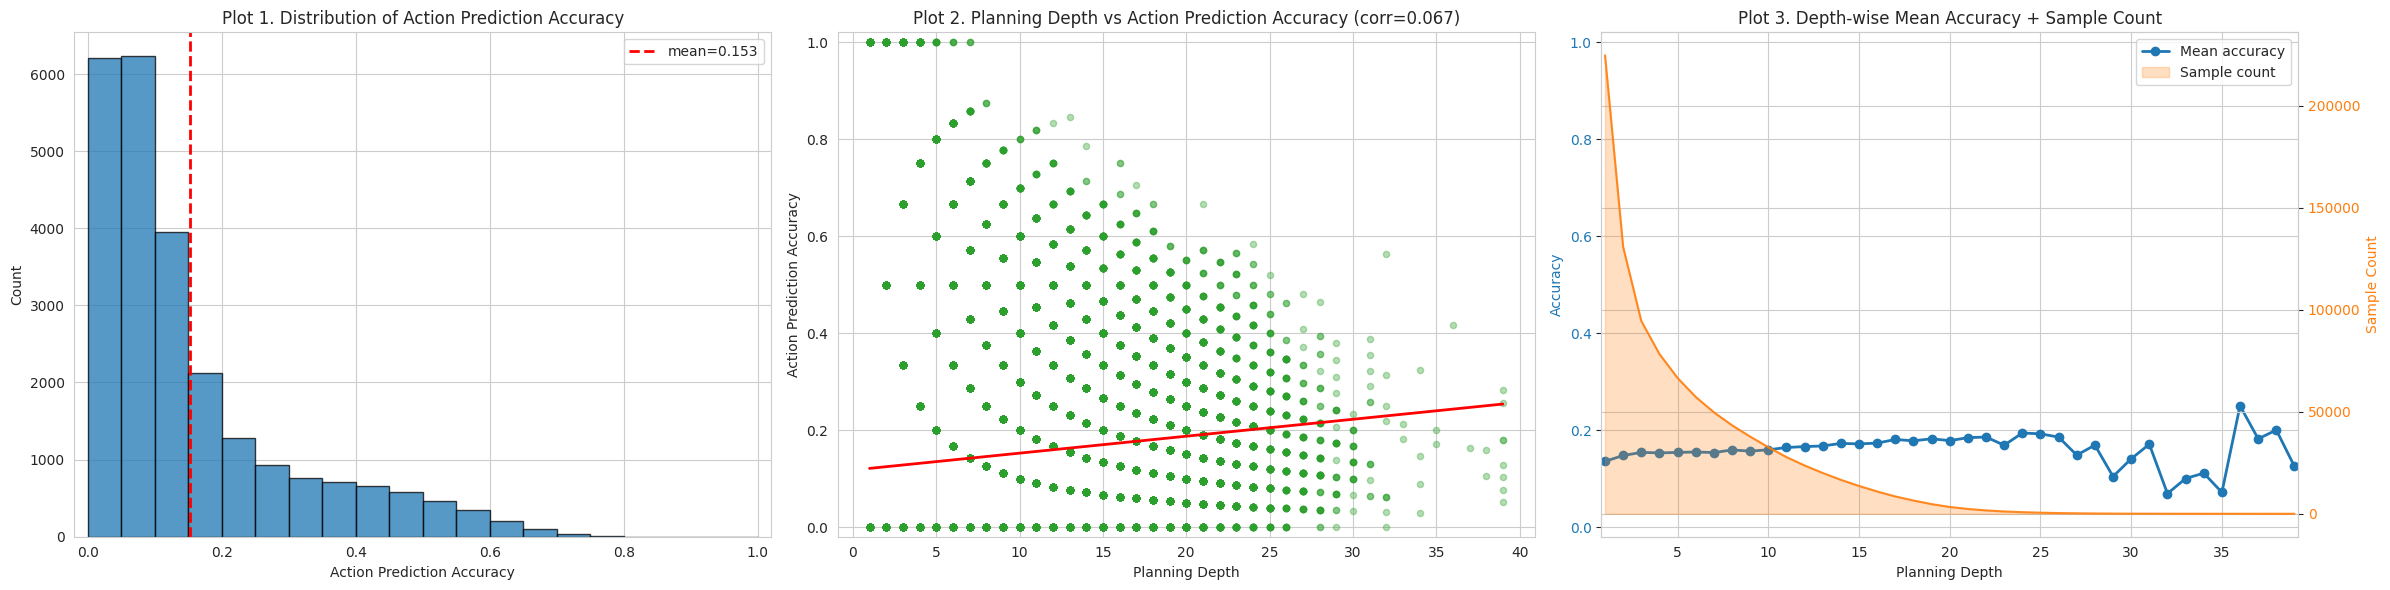

=== Summary ===
Real-step samples: 24589
Segment samples : 224637
Depth-step samples: 958653
Action Prediction Accuracy (real-step mean ± std): 0.1526 ± 0.1492


In [10]:
inputs = ["test/sub001"]
real_rows, segment_rows, depth_step_rows = analyze_multiple_files(inputs, recursive=True)
visualize_action_prediction_accuracy(real_rows, segment_rows, depth_step_rows, bins=20)